# 08 — Disparity figures (SMD plots)

Visualizations of the scenario-level SMDs computed in notebook 07. The main paper figure is the **stacked-models plot for the `direct_audio` condition at 1 % winsorization** — one row per model, race-SMD contrasts as blue circles, gender-SMD contrasts as orange squares, 95 % participant-cluster bootstrap CIs as error bars. This notebook produces that figure plus several adjacent views: the same plot without winsorization, the transcript-conditioned variants, a per-prompt strip plot (one step before scenario aggregation) for inspecting whether a scenario-level signal comes from one extreme prompt or is systematic, and a combined-conditions plot per model.

**Main vs complementary figures.** Recruitment was stratified on `race × gender` (not accent), so race and gender are the load-bearing axes for the statistical claims. The main paper files (`*.{png,pdf}` with the unsuffixed filenames) plot only those two axes. Every plot is *also* rendered with the accent axis added (green triangles) into a sibling file with the `__with_accent` suffix — descriptive, not load-bearing.

All axes inherit from `AXIS_STYLES` below — adding a fourth axis upstream (e.g., expert-labeled accent) only needs a new entry there.

**Tables-only views** of the same content are produced in notebook 09; **figures live here**.

**Inputs:** `../data/model_outputs/disparity/{scenario_smds_with_ci,prompt_level_smds}.csv`  
**Outputs:** PNG + PDF figures under `../paper/figures/smd/` and `../paper/figures/smd_per_prompt/`.

## Setup + plotting style

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd().parent
DISP = REPO_ROOT / "data" / "model_outputs" / "disparity"
SMD_DIR        = REPO_ROOT / "paper" / "figures" / "smd"
SMD_STRIP_DIR  = REPO_ROOT / "paper" / "figures" / "smd_per_prompt"
SMD_DIR.mkdir(parents=True, exist_ok=True)
SMD_STRIP_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "serif", "font.size": 12,
    "axes.titlesize": 14, "axes.labelsize": 14,
    "legend.fontsize": 12, "xtick.labelsize": 13, "ytick.labelsize": 13,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
sns.set_style("whitegrid")

In [2]:
# Per-axis plotting style — colors and markers, keyed by the disparity.AXES axis name.
# Adding a fourth axis upstream just needs one more entry here.
AXIS_STYLES = {
    "race":   {"color": "#1f77b4", "marker": "o", "label": "Race",   "sign": "Black − White"},
    "gender": {"color": "#ff7f0e", "marker": "s", "label": "Gender", "sign": "Female − Male"},
    "accent": {"color": "#2ca02c", "marker": "^", "label": "Accent", "sign": "non-SAE − SAE"},
}
AXES_ORDER  = list(AXIS_STYLES.keys())

# Main paper figures use ONLY the axes recruitment was stratified on (race + gender):
# those are the load-bearing claims. Accent is in the complementary "with_accent"
# figures alongside, written to the same directory with a "__with_accent" suffix.
MAIN_AXES   = ["race", "gender"]
SUFFIX_ACCENT = "with_accent"

# Convenience aliases (still referenced by a few cells; new code should read from AXIS_STYLES).
SMD_RACE_COLOR   = AXIS_STYLES["race"]["color"]
SMD_GENDER_COLOR = AXIS_STYLES["gender"]["color"]
SMD_ACCENT_COLOR = AXIS_STYLES["accent"]["color"]

CONDITION_MARKERS = {
    "direct_audio_response":        "o",
    "external_transcript_response": "s",
    "self_transcript_response":     "^",
}
CONDITION_LABELS = {
    "direct_audio_response":        "audio",
    "external_transcript_response": "ext_transcript",
    "self_transcript_response":     "self_transcript",
}
MODEL_DISPLAY_LABEL = {
    "Qwen/Qwen2.5-Omni-7B":              "Qwen2.5-Omni-7B",
    "gpt-audio-1.5":                     "GPT-Audio-1.5",
    "gemini-3.1-flash-lite-preview":     "Gemini-3.1-flash-lite",
    "gemini-3.5-flash":                  "Gemini-3.5-Flash",
    "gemini-3.1-pro-preview":            "Gemini-3.1-Pro",
    "moonshotai/Kimi-Audio-7B-Instruct": "Kimi-Audio-7B",
}
MODELS_ORDER = [
    "gemini-3.1-flash-lite-preview", "gemini-3.5-flash", "gemini-3.1-pro-preview",
    "gpt-audio-1.5", "Qwen/Qwen2.5-Omni-7B", "moonshotai/Kimi-Audio-7B-Instruct",
]
# 11 thematic scenarios; the SMD CSV's scenario column carries these names.
SCENARIO_LABEL = {
    "Caring Household Members":       "Caring Household",
    "Civic and Religious Activities": "Civic and Religious",
    "Educational Activities":          "Educational",
    "Finance":                         "Finance",
    "Health":                          "Health",
    "Household Activities":            "Household",
    "Leisure and Sports":              "Leisure & Sports",
    "Personal Care":                   "Personal Care",
    "Politics":                        "Politics",
    "Purchasing Goods and Services":   "Purchases",
    "Work-related Activities":         "Work-related",
}

def _short(scen):    return SCENARIO_LABEL.get(scen, scen)
def _model_label(m): return MODEL_DISPLAY_LABEL.get(m, m)

def _zero_line(ax):
    """Solid black y=0 reference, slightly heavier than the seaborn grid."""
    ax.axhline(0, color="black", linestyle="-", linewidth=1.0, alpha=0.85, zorder=0.5)

def _axis_offsets(n_axes, half_width=None):
    """Horizontal jitter offsets for `n_axes` markers within one scenario bin.

    Default half_width = 0.10 for n=2 and 0.16 for n=3 keeps within-scenario
    markers tight while leaving wide gaps between scenarios.
    """
    if n_axes == 1:
        return [0.0]
    if half_width is None:
        half_width = 0.10 if n_axes <= 2 else 0.16
    return list(np.linspace(-half_width, half_width, n_axes))

def _accent_suffix(axes_order):
    """Returns '__with_accent' when accent is in axes_order, else ''."""
    return f"__{SUFFIX_ACCENT}" if "accent" in axes_order else ""

# Figure-width and height tuning — wider per-scenario than before so within-scenario
# markers can sit close together while still leaving generous whitespace between
# adjacent scenarios.
WIDTH_PER_SCEN = 1.15      # inches per scenario bin
WIDTH_MIN      = 13.0      # minimum figure width
HEIGHT_PER_ROW = 2.8       # stacked-models plot row height (inches)

In [3]:
sc      = pd.read_csv(DISP / "scenario_smds_with_ci.csv")
prompts = pd.read_csv(DISP / "prompt_level_smds.csv")
print(f"scenario_smds_with_ci: {len(sc)} rows")
print(f"prompt_level_smds   : {len(prompts)} rows")
print("\ncoverage (model × condition × winsorize):")
print(sc.groupby(["model_id", "condition", "winsorize_pct"]).size().to_string())

scenario_smds_with_ci: 396 rows
prompt_level_smds   : 544 rows

coverage (model × condition × winsorize):
model_id                       condition                     winsorize_pct
Qwen/Qwen2.5-Omni-7B           direct_audio_response         0.01             33
                               external_transcript_response  0.01             33
gemini-3.1-flash-lite-preview  direct_audio_response         0.01             33
                               external_transcript_response  0.01             33
                               self_transcript_response      0.01             33
gpt-audio-1.5                  direct_audio_response         0.01             33


## 1. SMD axis helper + per-(model × condition × winsorize) plot

`_draw_scenario_smd_axis` is the single drawing primitive shared by every plot in this notebook: 11 scenarios on the x-axis, one marker per axis in `axes_order` jittered tightly around each scenario position, error bars from the 95 % bootstrap CI.

Each plotting function below is called **twice**: once with `axes_order = MAIN_AXES` (race + gender — the load-bearing recruitment axes) and once with `axes_order = AXES_ORDER` (all three axes, including accent). The race+gender outputs keep their original filenames; the three-axis outputs add a `__with_accent` suffix.

In [4]:
def _draw_scenario_smd_axis(ax, sc_df, scenarios, axes_order):
    """One marker per axis × scenario, with bootstrap-CI error bars."""
    offsets = _axis_offsets(len(axes_order))
    for axis_name, dx in zip(axes_order, offsets):
        style = AXIS_STYLES[axis_name]
        sub = sc_df[sc_df["axis"] == axis_name].set_index("scenario").reindex(scenarios)
        for i, scen in enumerate(scenarios):
            if scen not in sub.index or pd.isna(sub.loc[scen, "point"]):
                continue
            row = sub.loc[scen]
            point = row["point"]; lo = row["ci_lo"]; hi = row["ci_hi"]
            err_lo = point - lo if pd.notna(lo) else 0.0
            err_hi = hi - point if pd.notna(hi) else 0.0
            ax.errorbar([i + dx], [point],
                          yerr=[[err_lo], [err_hi]],
                          fmt=style["marker"], color=style["color"], ecolor=style["color"],
                          markerfacecolor=style["color"], markersize=7.0,
                          markeredgecolor="white", markeredgewidth=0.4,
                          capsize=3.5,
                          label=style["label"] if i == 0 else None)
    _zero_line(ax)


def plot_scenario_smds(sc_df, model_id, condition, winsorize_pct,
                        axes_order=MAIN_AXES, save_dir=SMD_DIR, show=True,
                        extra_suffix=""):
    """Single (model × condition × winsorize) scenario-SMD figure."""
    if sc_df is None or len(sc_df) == 0:
        return None
    scenarios = sorted(sc_df["scenario"].unique())
    n_scen = len(scenarios)
    fig, ax = plt.subplots(figsize=(max(WIDTH_MIN, WIDTH_PER_SCEN * n_scen + 4), 4.5))
    _draw_scenario_smd_axis(ax, sc_df, scenarios, axes_order)
    ax.set_xticks(np.arange(n_scen))
    ax.set_xticklabels([_short(s) for s in scenarios], rotation=20, ha="right")
    ax.set_ylabel("Standardized Mean Difference")
    ax.legend(loc="upper right", frameon=True)
    ax.margins(x=0.02)
    fig.tight_layout()
    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        safe_m = model_id.replace("/", "_").replace(":", "_")
        wstem = "raw" if not winsorize_pct else f"wins{int(winsorize_pct * 100)}"
        stem  = f"{safe_m}__{condition}__scenario_smds__{wstem}{_accent_suffix(axes_order)}{extra_suffix}"
        fig.savefig(save_dir / f"{stem}.png")
        fig.savefig(save_dir / f"{stem}.pdf")
    if show:  plt.show()
    else:     plt.close(fig)
    return fig


# One figure per (model × condition × winsorize) — the most granular per-cell view.
# Rendered twice: race+gender (main) and race+gender+accent (with_accent).
n_rendered = 0
for axes_choice in (MAIN_AXES, AXES_ORDER):
    for w in [None, 0.01]:
        for cond in sorted(sc["condition"].unique()):
            for m in sorted(sc.loc[sc["condition"] == cond, "model_id"].unique()):
                sub = sc[(sc["model_id"] == m) & (sc["condition"] == cond)
                           & ((sc["winsorize_pct"] == w) if w is not None else sc["winsorize_pct"].isna())]
                if sub.empty:
                    continue
                plot_scenario_smds(sub, m, cond, w, axes_order=axes_choice,
                                    save_dir=SMD_DIR, show=False)
                n_rendered += 1
print(f"rendered {n_rendered} per-(model × condition × winsorize) figures into {SMD_DIR.relative_to(REPO_ROOT)}/")

rendered 24 per-(model × condition × winsorize) figures into paper/figures/smd/


## 2. Main paper figure — three-model stacked plot, `direct_audio` × winsorize=1 %

Rows are the three audio-language models; each row is one scenario-SMD axis with race (blue circles) and gender (orange squares) markers and 95 % bootstrap CIs. Shared x-axis (11 scenarios) and shared y-axis so SMD magnitudes are visually comparable across models.

**Two figures are emitted:**
- `direct_audio_response__models_stacked__wins1.{png,pdf}` — **main paper figure**, race + gender only. These are the axes recruitment was stratified on (and powered for), so they carry the load-bearing statistical claims.
- `direct_audio_response__models_stacked__wins1__with_accent.{png,pdf}` — complementary figure adding the accent axis (green triangles). Accent is descriptive only (recruitment wasn't stratified on it; the axis co-varies with race by construction — see notebook 07 § 1 for the rationale).

--- main (race + gender) ---


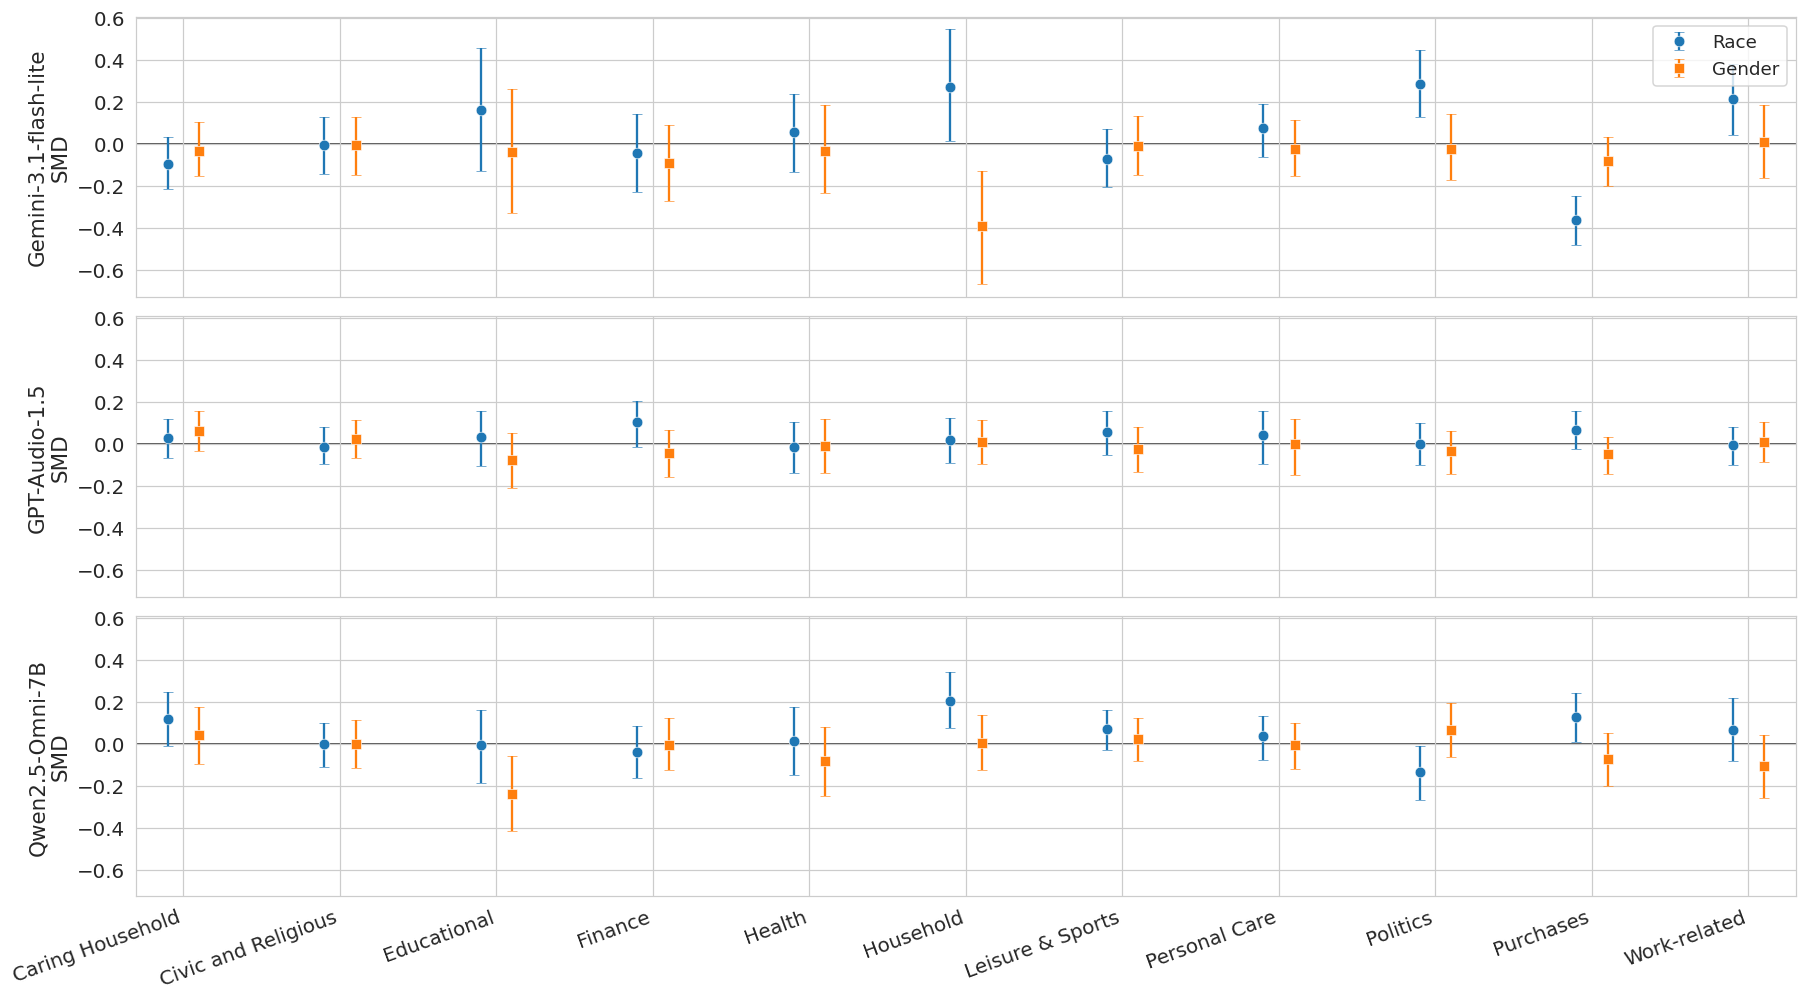

--- with_accent (race + gender + accent) ---


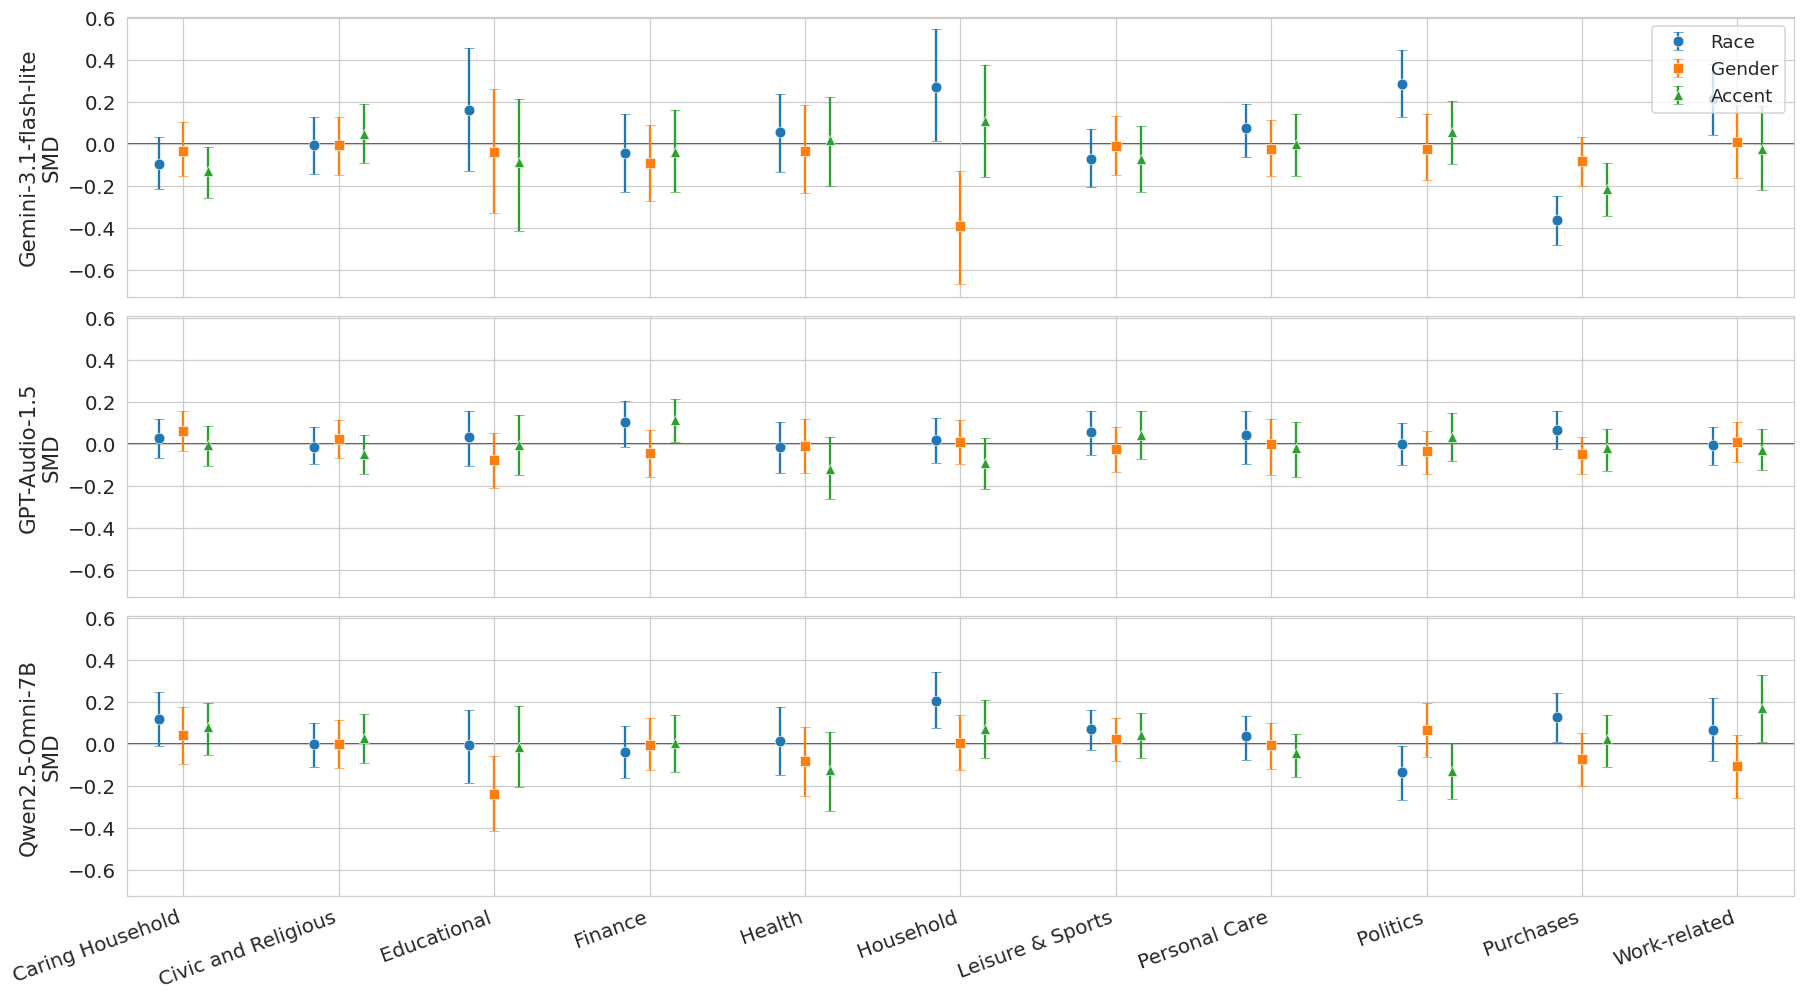

In [5]:
def plot_models_stacked(sc_df, condition, winsorize_pct,
                         axes_order=MAIN_AXES,
                         models_order=MODELS_ORDER,
                         save_dir=SMD_DIR, show=True, sharey=True,
                         extra_suffix=""):
    """One figure per (condition × winsorize). Rows = models that ran this condition."""
    wmask = sc_df["winsorize_pct"].isna() if winsorize_pct is None else (sc_df["winsorize_pct"] == winsorize_pct)
    sub = sc_df[wmask & (sc_df["condition"] == condition)].copy()
    if sub.empty:
        return None

    rows = []
    for m in models_order:
        msub = sub[sub["model_id"] == m]
        if not msub.empty:
            rows.append((m, msub))
    if not rows:
        return None

    scenarios = sorted({s for _, df_ in rows for s in df_["scenario"].unique()})
    n_rows = len(rows); n_scen = len(scenarios)
    fig, axes = plt.subplots(n_rows, 1,
                                figsize=(max(WIDTH_MIN, WIDTH_PER_SCEN * n_scen + 4),
                                          HEIGHT_PER_ROW * n_rows + 0.8),
                                sharex=True, sharey=sharey, squeeze=False)
    axes = axes[:, 0]

    for i, (m, sc_) in enumerate(rows):
        ax = axes[i]
        _draw_scenario_smd_axis(ax, sc_, scenarios, axes_order)
        ax.set_ylabel(f"{_model_label(m)}\nSMD")
        if i == 0:
            ax.legend(loc="upper right", frameon=True)
        ax.margins(x=0.02)

    axes[-1].set_xticks(np.arange(n_scen))
    axes[-1].set_xticklabels([_short(s) for s in scenarios], rotation=20, ha="right")
    fig.tight_layout()

    if save_dir is not None:
        wstem = "raw" if winsorize_pct is None else f"wins{int(winsorize_pct * 100)}"
        stem  = f"{condition}__models_stacked__{wstem}{_accent_suffix(axes_order)}{extra_suffix}"
        fig.savefig(save_dir / f"{stem}.png")
        fig.savefig(save_dir / f"{stem}.pdf")
    if show:  plt.show()
    else:     plt.close(fig)
    return fig


# Main paper figure (race + gender only) and the with_accent companion.
print("--- main (race + gender) ---")
_ = plot_models_stacked(sc, condition="direct_audio_response", winsorize_pct=0.01,
                          axes_order=MAIN_AXES)
print("--- with_accent (race + gender + accent) ---")
_ = plot_models_stacked(sc, condition="direct_audio_response", winsorize_pct=0.01,
                          axes_order=AXES_ORDER)

## 3. Variants — no winsorization + transcript conditions

Same stacked-models layout, different cells:

1. **`direct_audio_response`, raw (no winsorization)** — sensitivity check for whether the 1 % winsorize is driving any of the headline signals.
2. **`external_transcript_response`, winsorize=1 %** — same models on a Whisper-1 transcript of the same audio.
3. **`self_transcript_response`, winsorize=1 %** — Gemini reading its own transcript (Gemini-only, single row).


=========== main (race+gender) ===========

--- direct_audio_response (winsorize=raw) ---


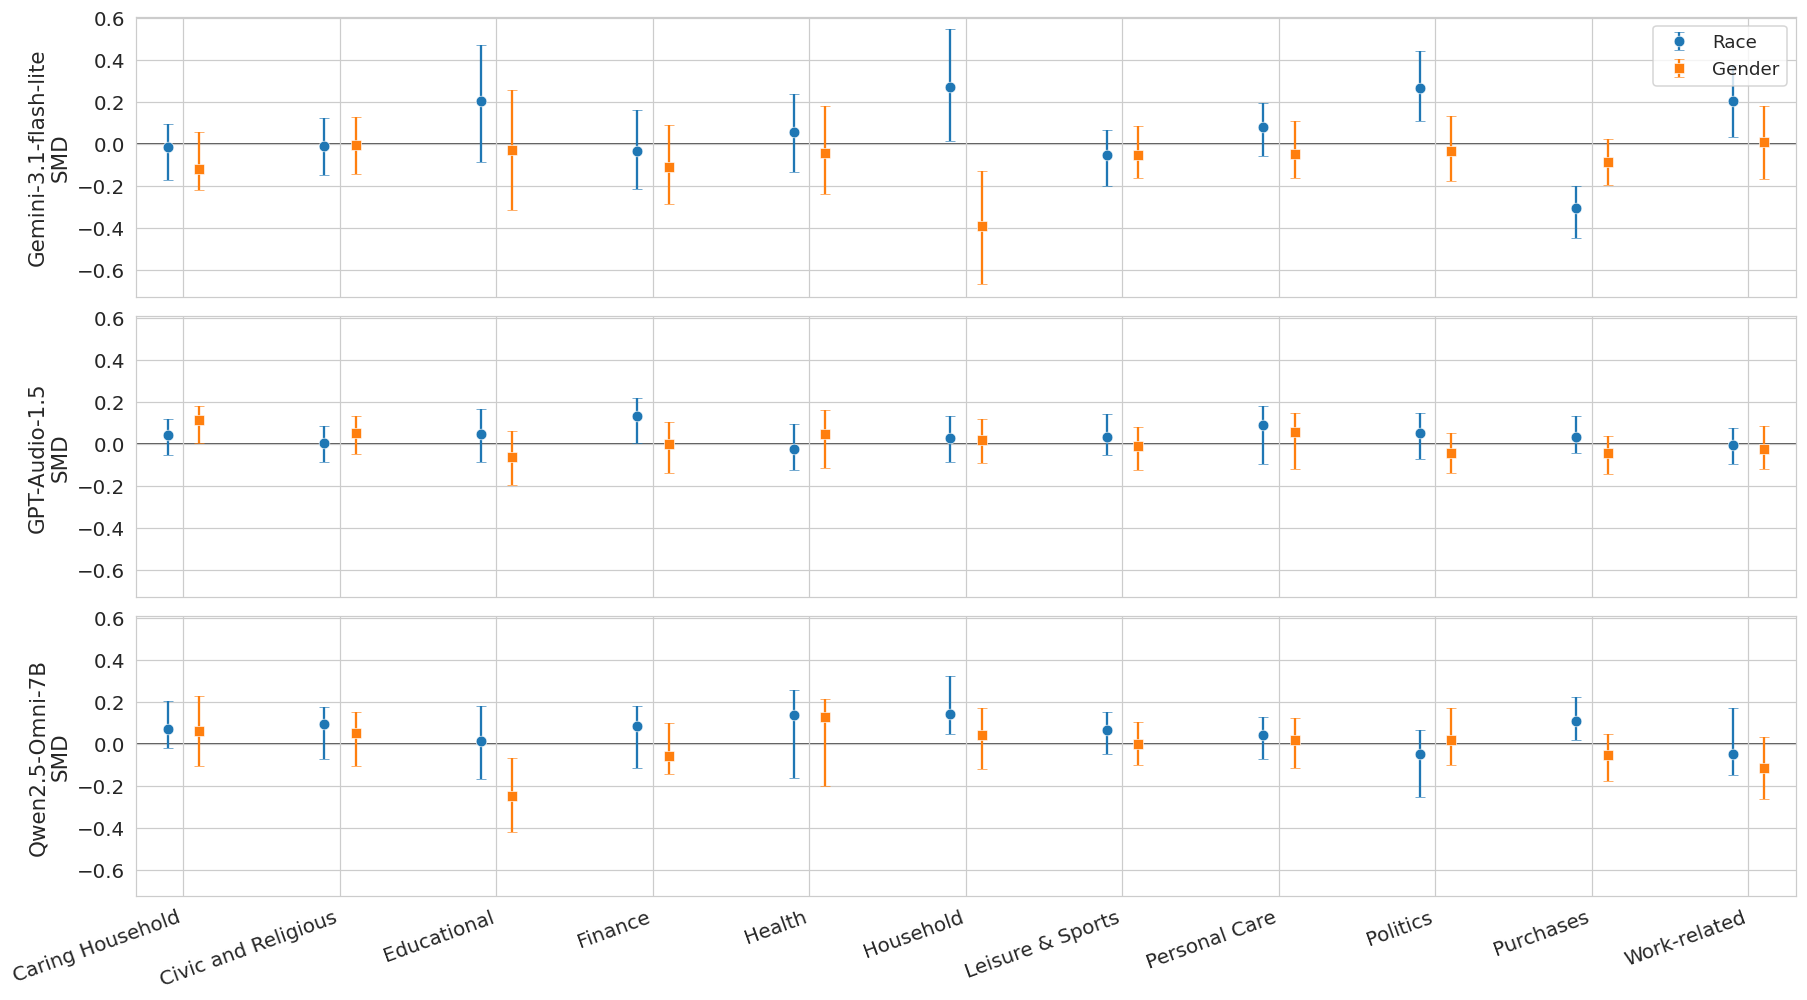


--- external_transcript_response (winsorize=1%) ---


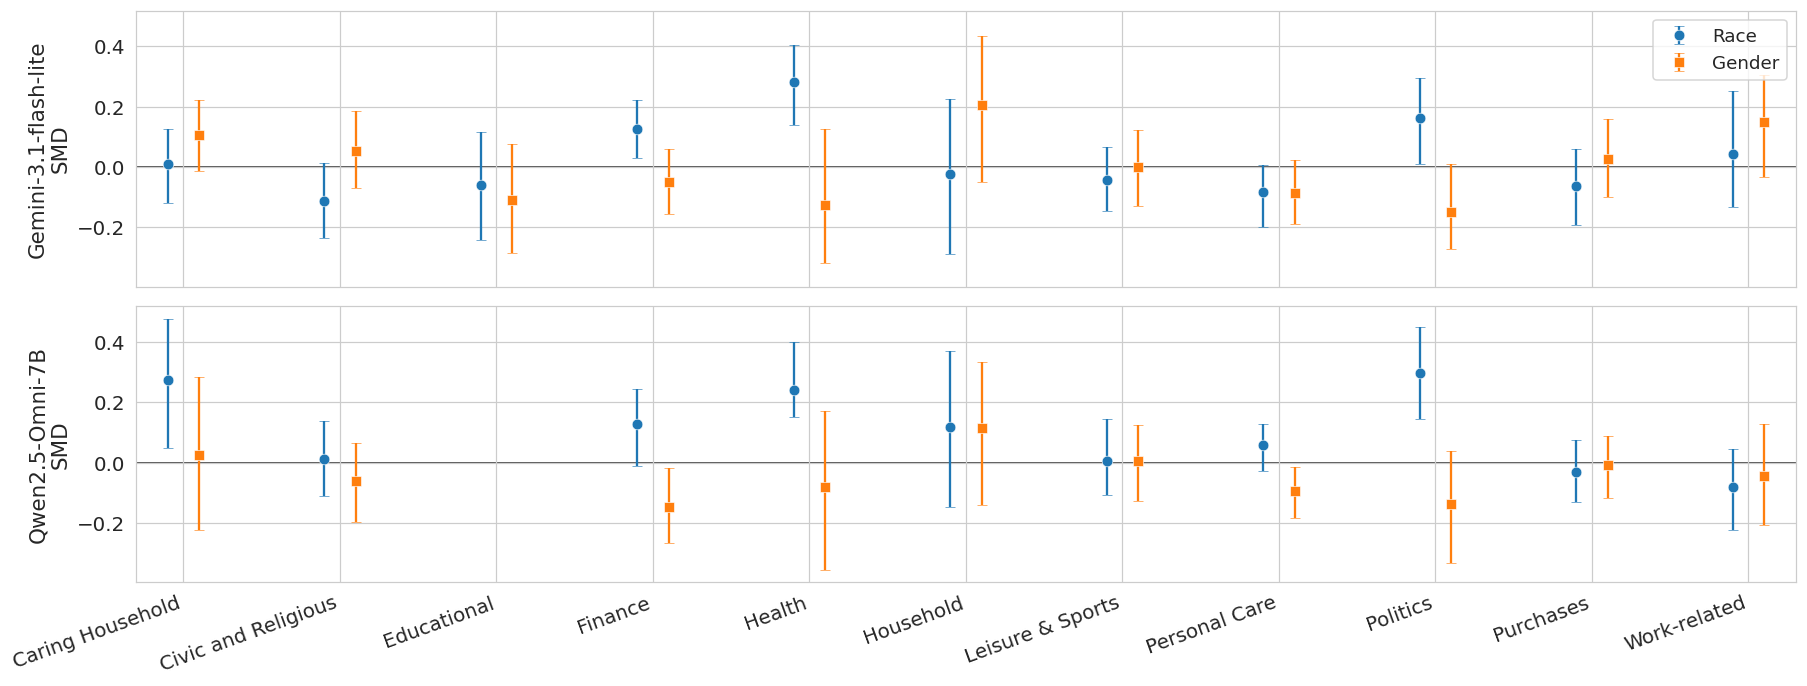


--- self_transcript_response (winsorize=1%) ---


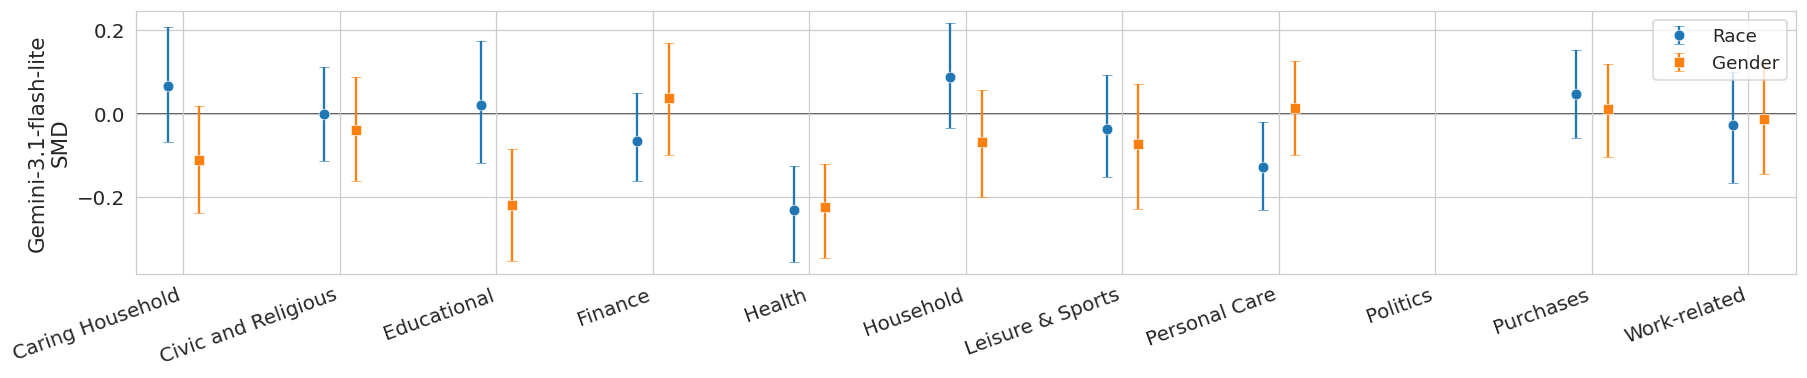


=========== with_accent (race+gender+accent) ===========

--- direct_audio_response (winsorize=raw) ---


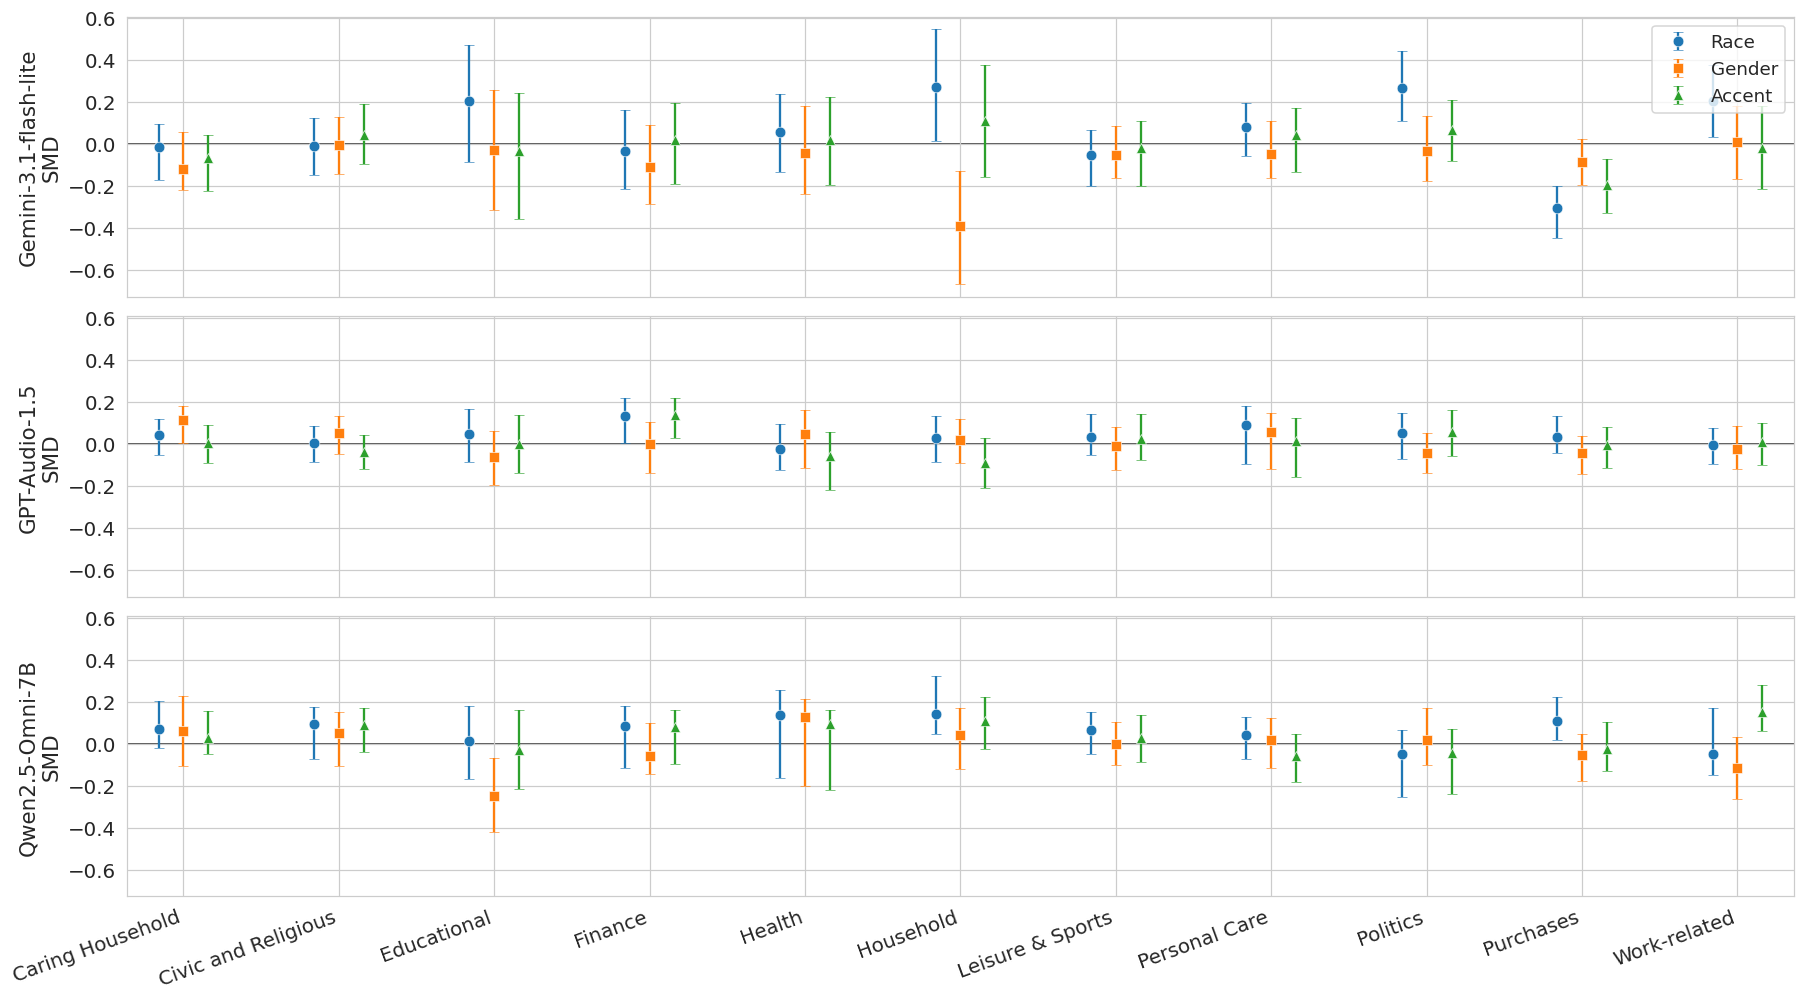


--- external_transcript_response (winsorize=1%) ---


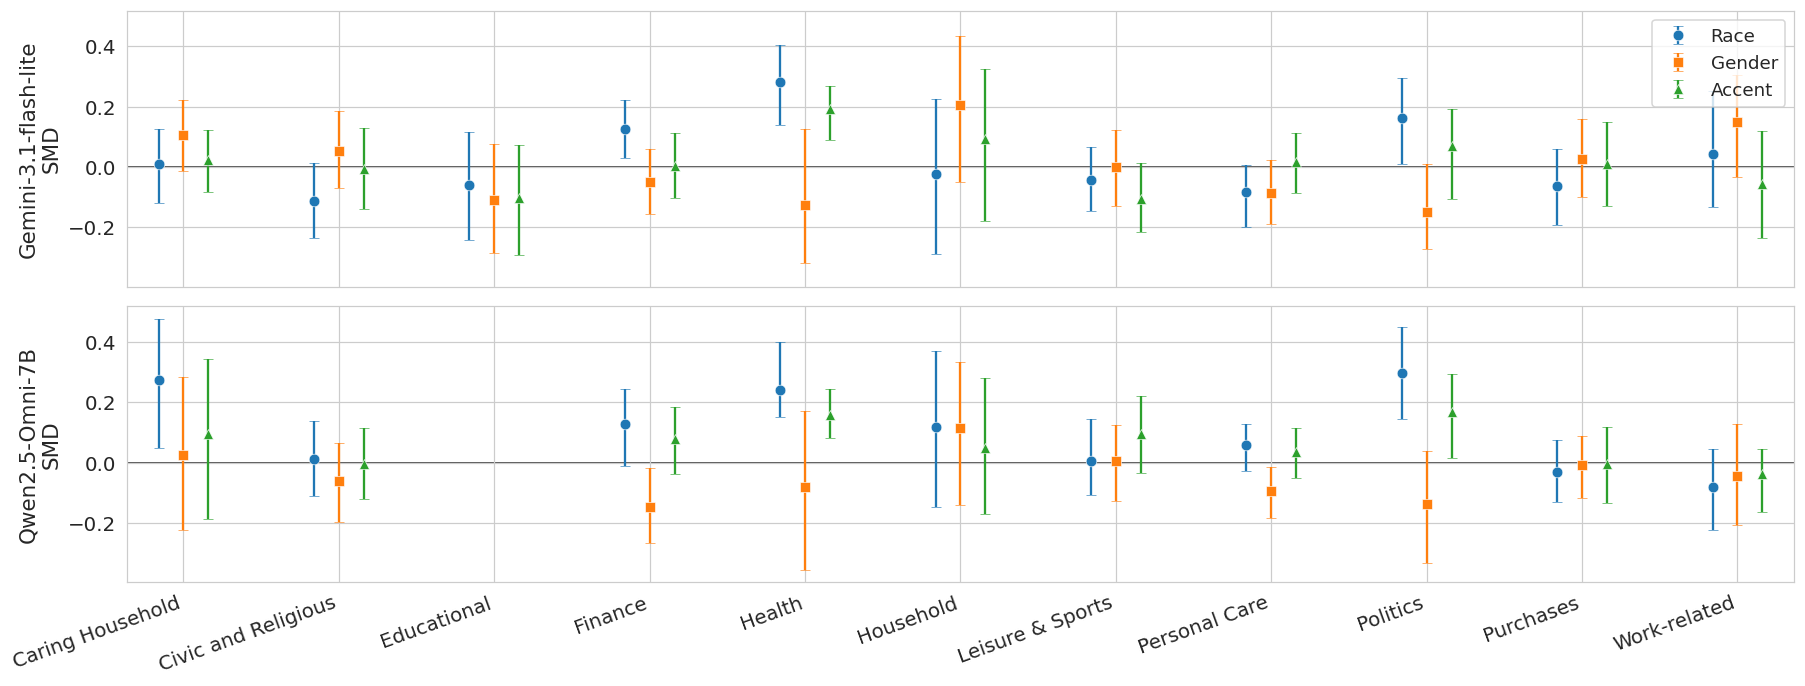


--- self_transcript_response (winsorize=1%) ---


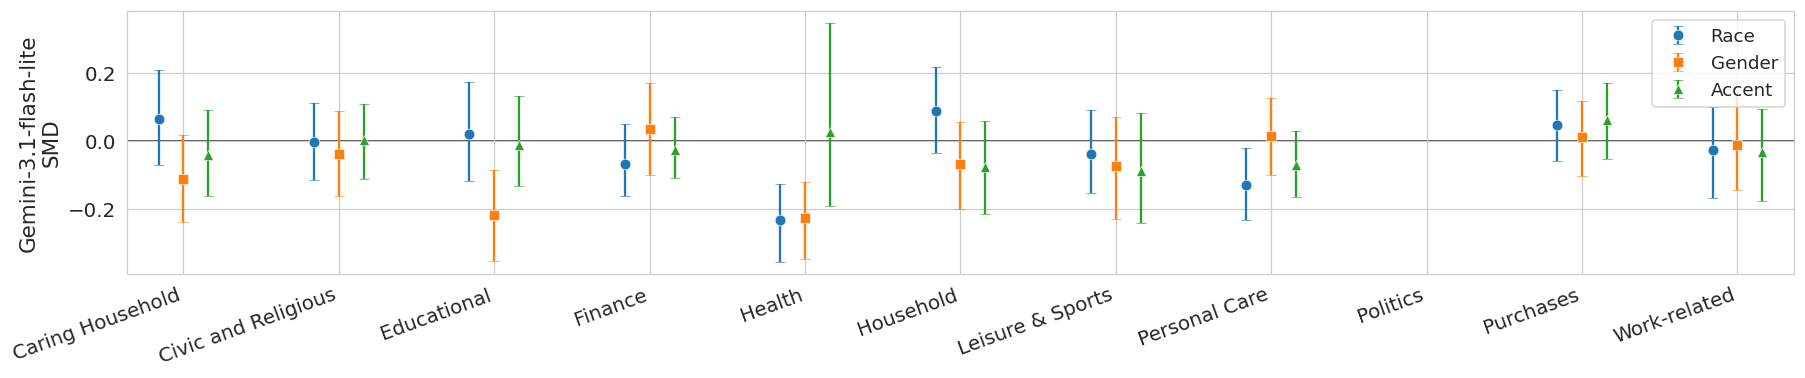

In [6]:
# Variants — emit both axes choices for every condition × winsorize variant.
for axes_choice in (MAIN_AXES, AXES_ORDER):
    label = "main (race+gender)" if axes_choice == MAIN_AXES else "with_accent (race+gender+accent)"
    print(f"\n=========== {label} ===========")
    for cond, w in [
        ("direct_audio_response",         None),
        ("external_transcript_response", 0.01),
        ("self_transcript_response",     0.01),
    ]:
        print(f"\n--- {cond} (winsorize={'raw' if w is None else '1%'}) ---")
        plot_models_stacked(sc, condition=cond, winsorize_pct=w, axes_order=axes_choice)

## 4. Combined-conditions plot per model

One figure per model: one row per axis (`axes_order`), each scenario carries one marker per condition the model ran (`o` audio, `s` ext-transcript, `^` self-transcript), markers jittered horizontally. Useful for inspecting whether a model's scenario-level SMDs shift across modalities.

Same two-output pattern as elsewhere — the main file (race + gender, two rows) and the `__with_accent` companion (three rows).


=========== main (race+gender) ===========
--- combined conditions: Gemini-3.1-flash-lite ---


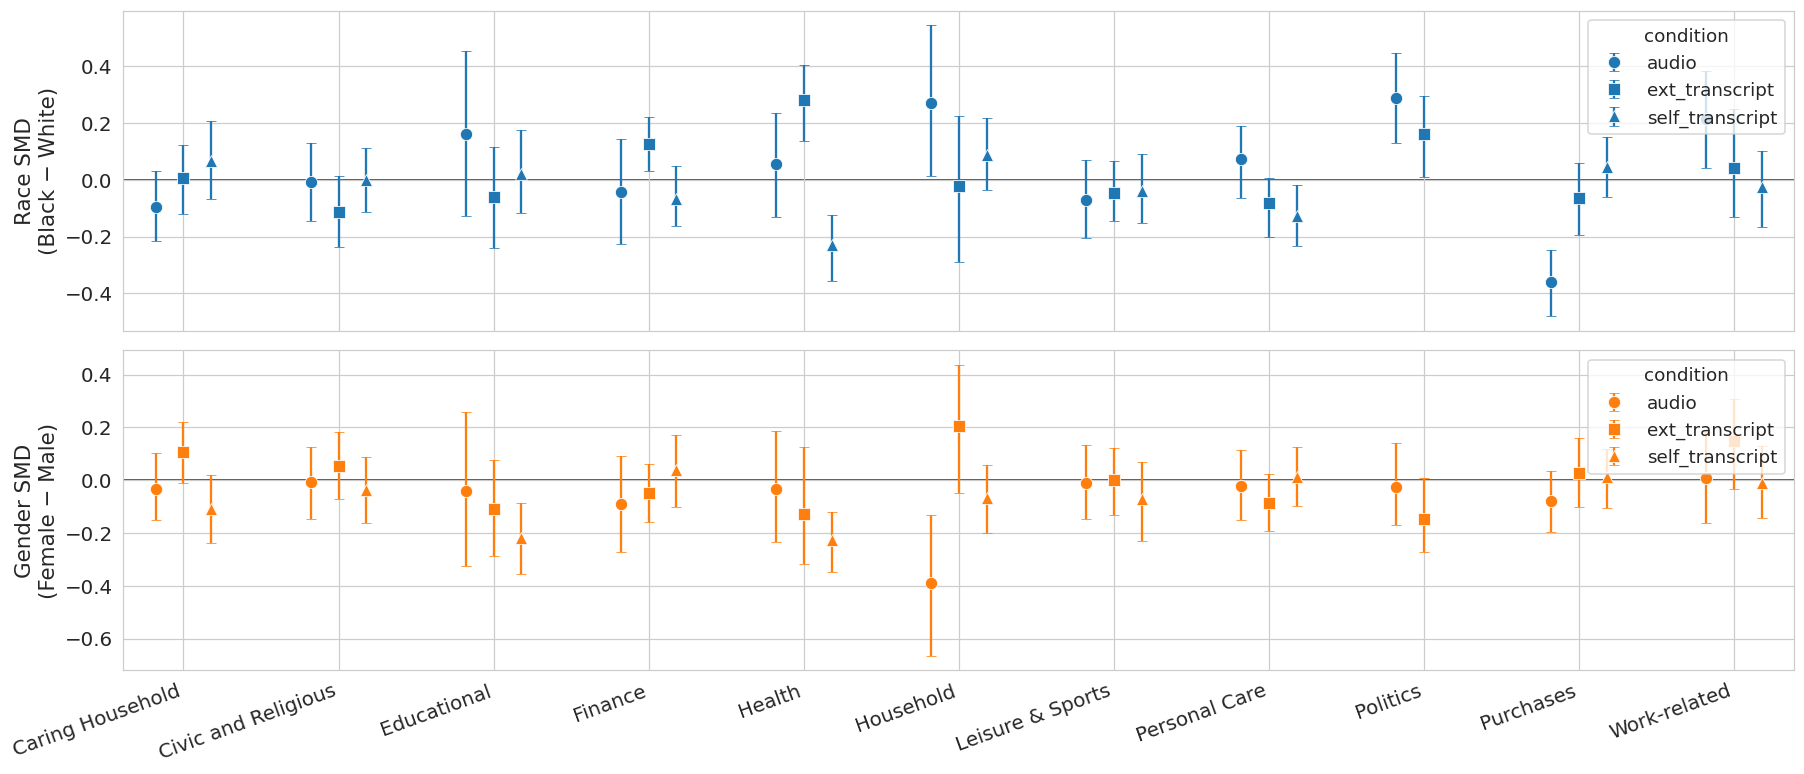

--- combined conditions: GPT-Audio-1.5 ---


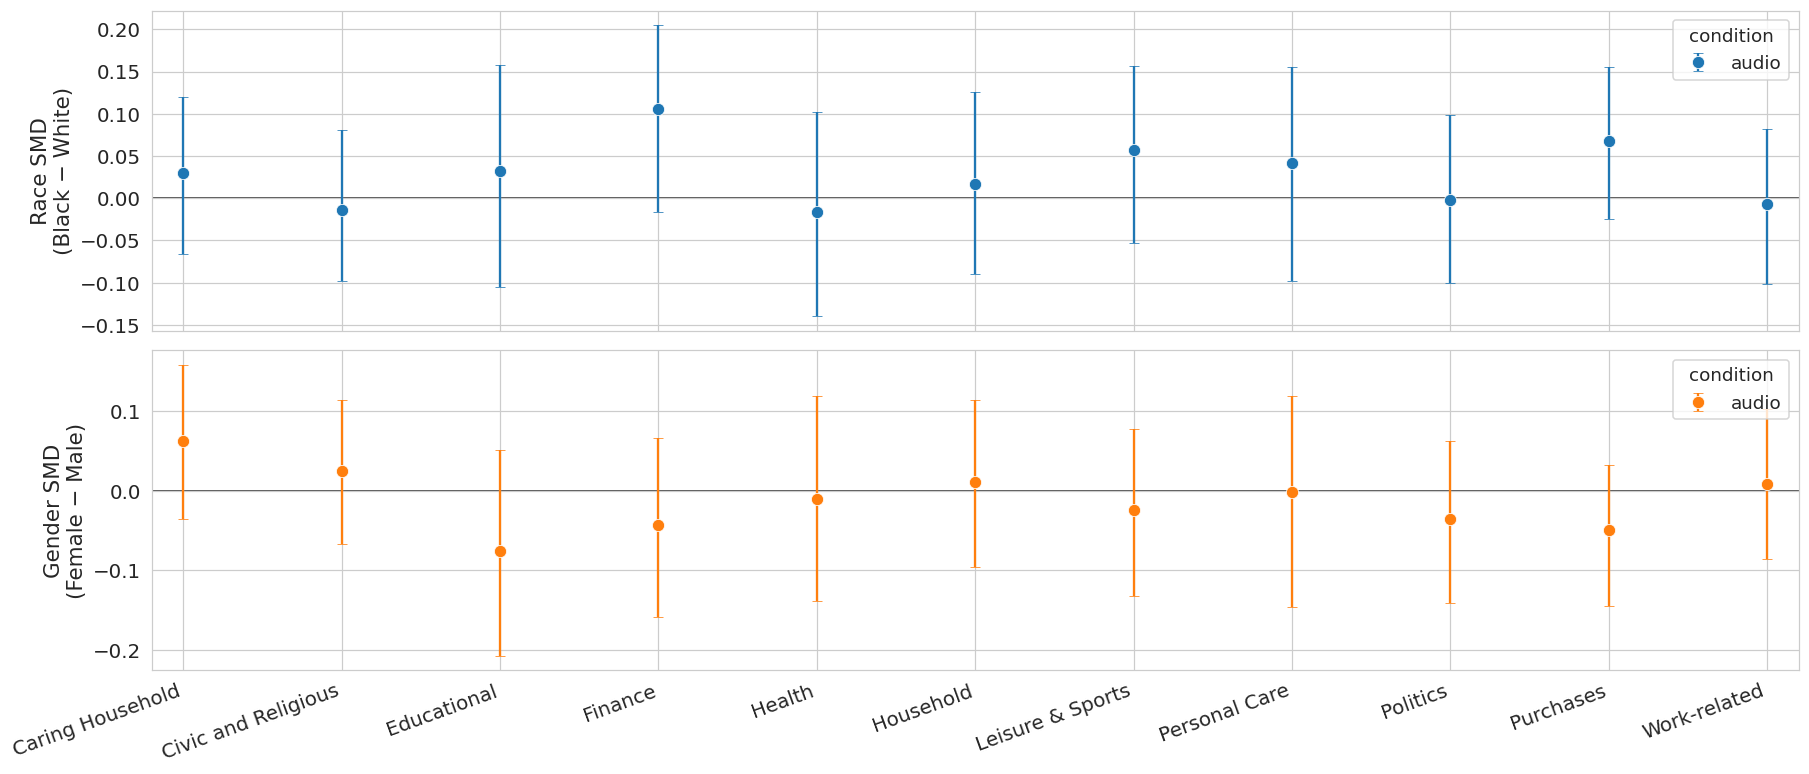

--- combined conditions: Qwen2.5-Omni-7B ---


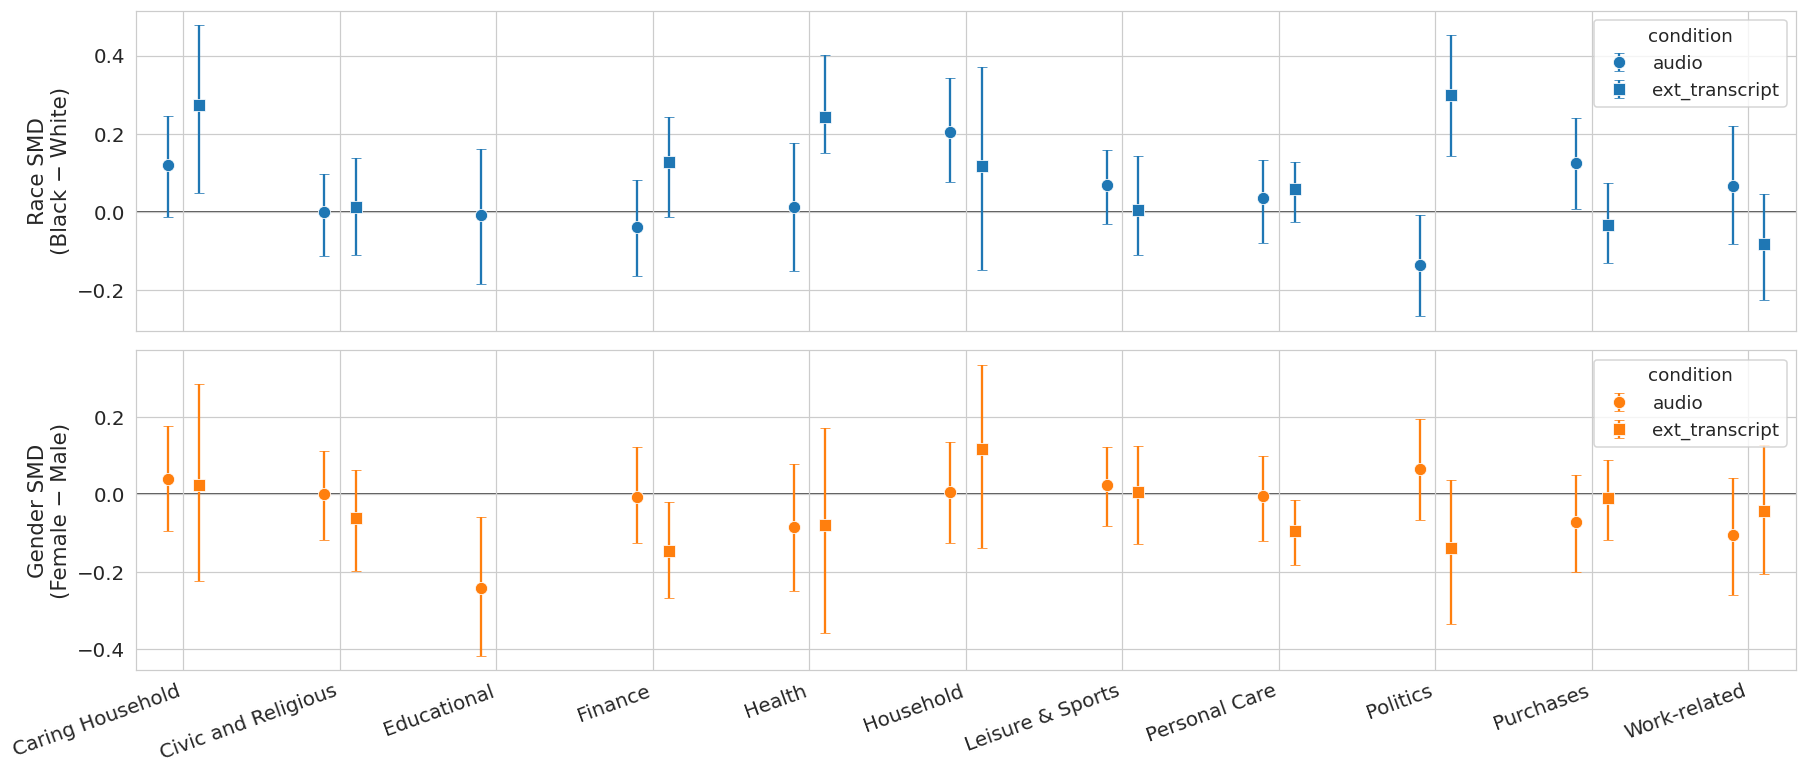


=========== with_accent (race+gender+accent) ===========
--- combined conditions: Gemini-3.1-flash-lite ---


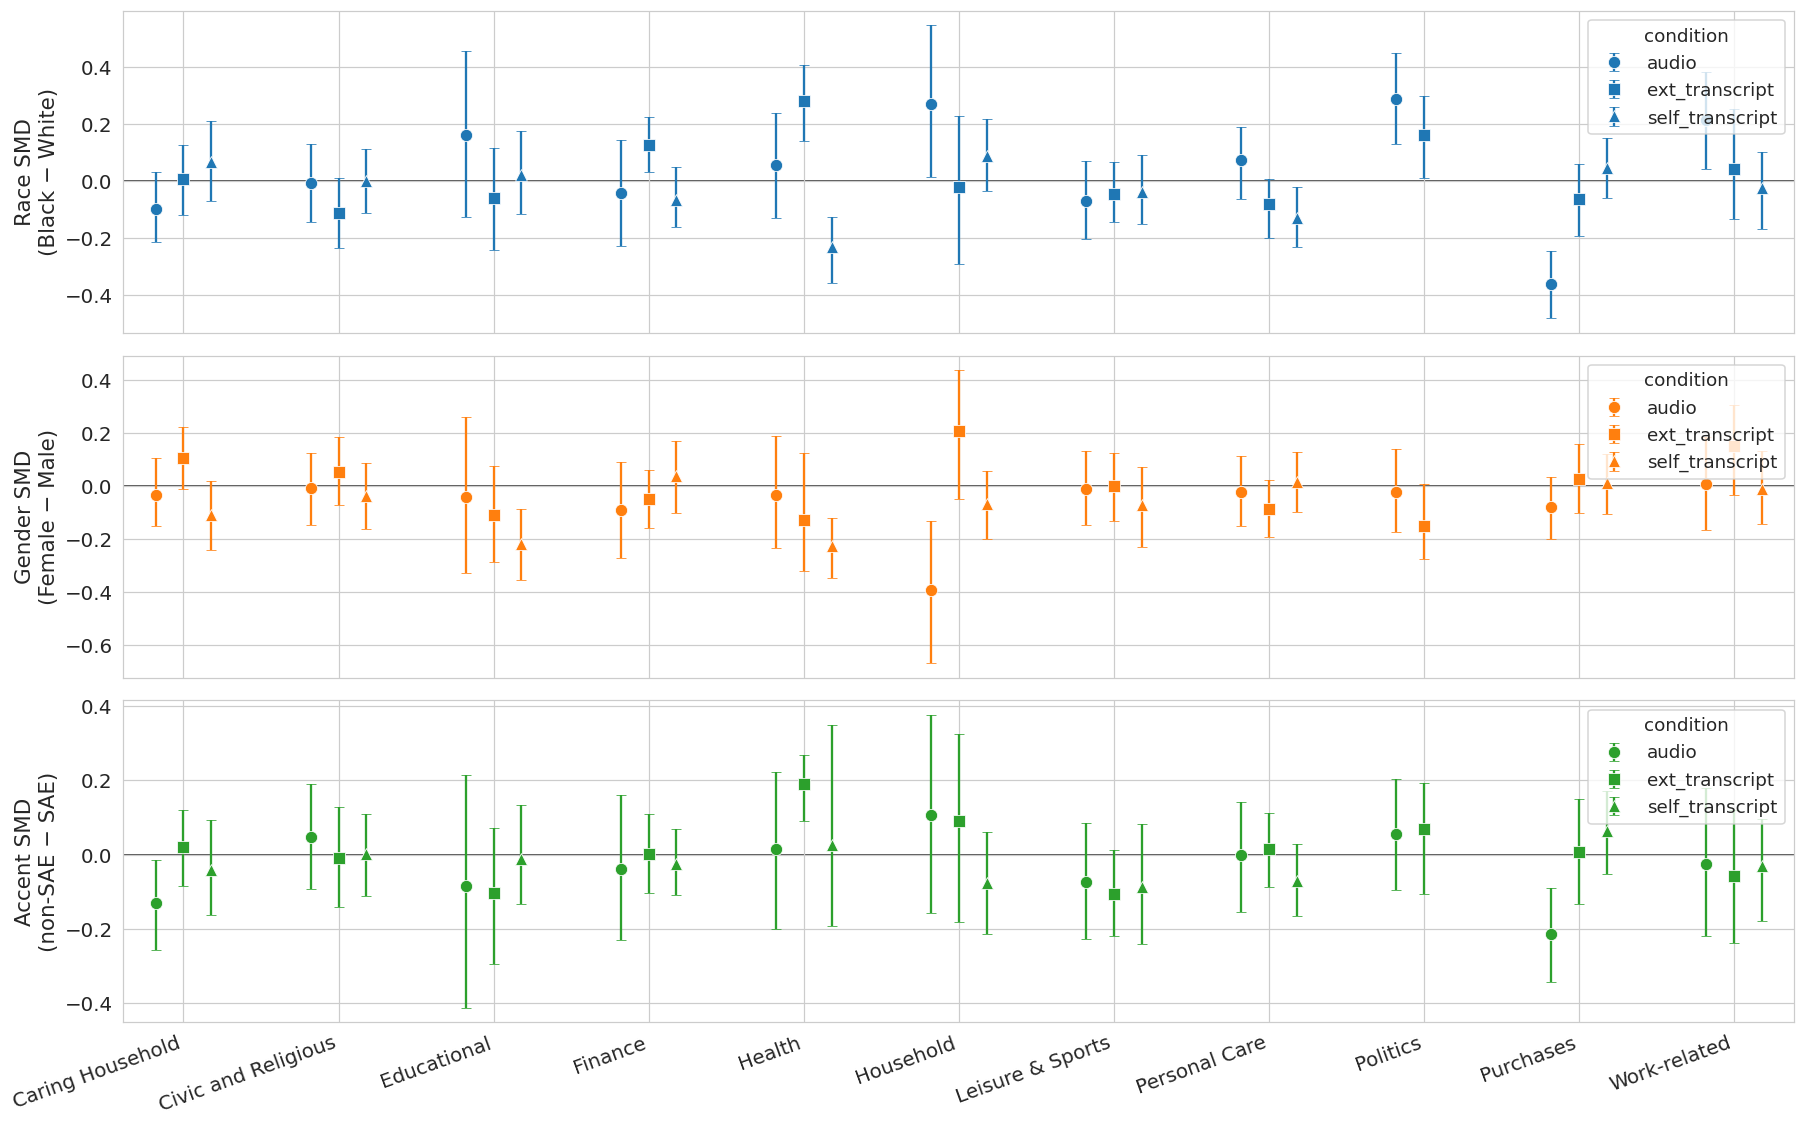

--- combined conditions: GPT-Audio-1.5 ---


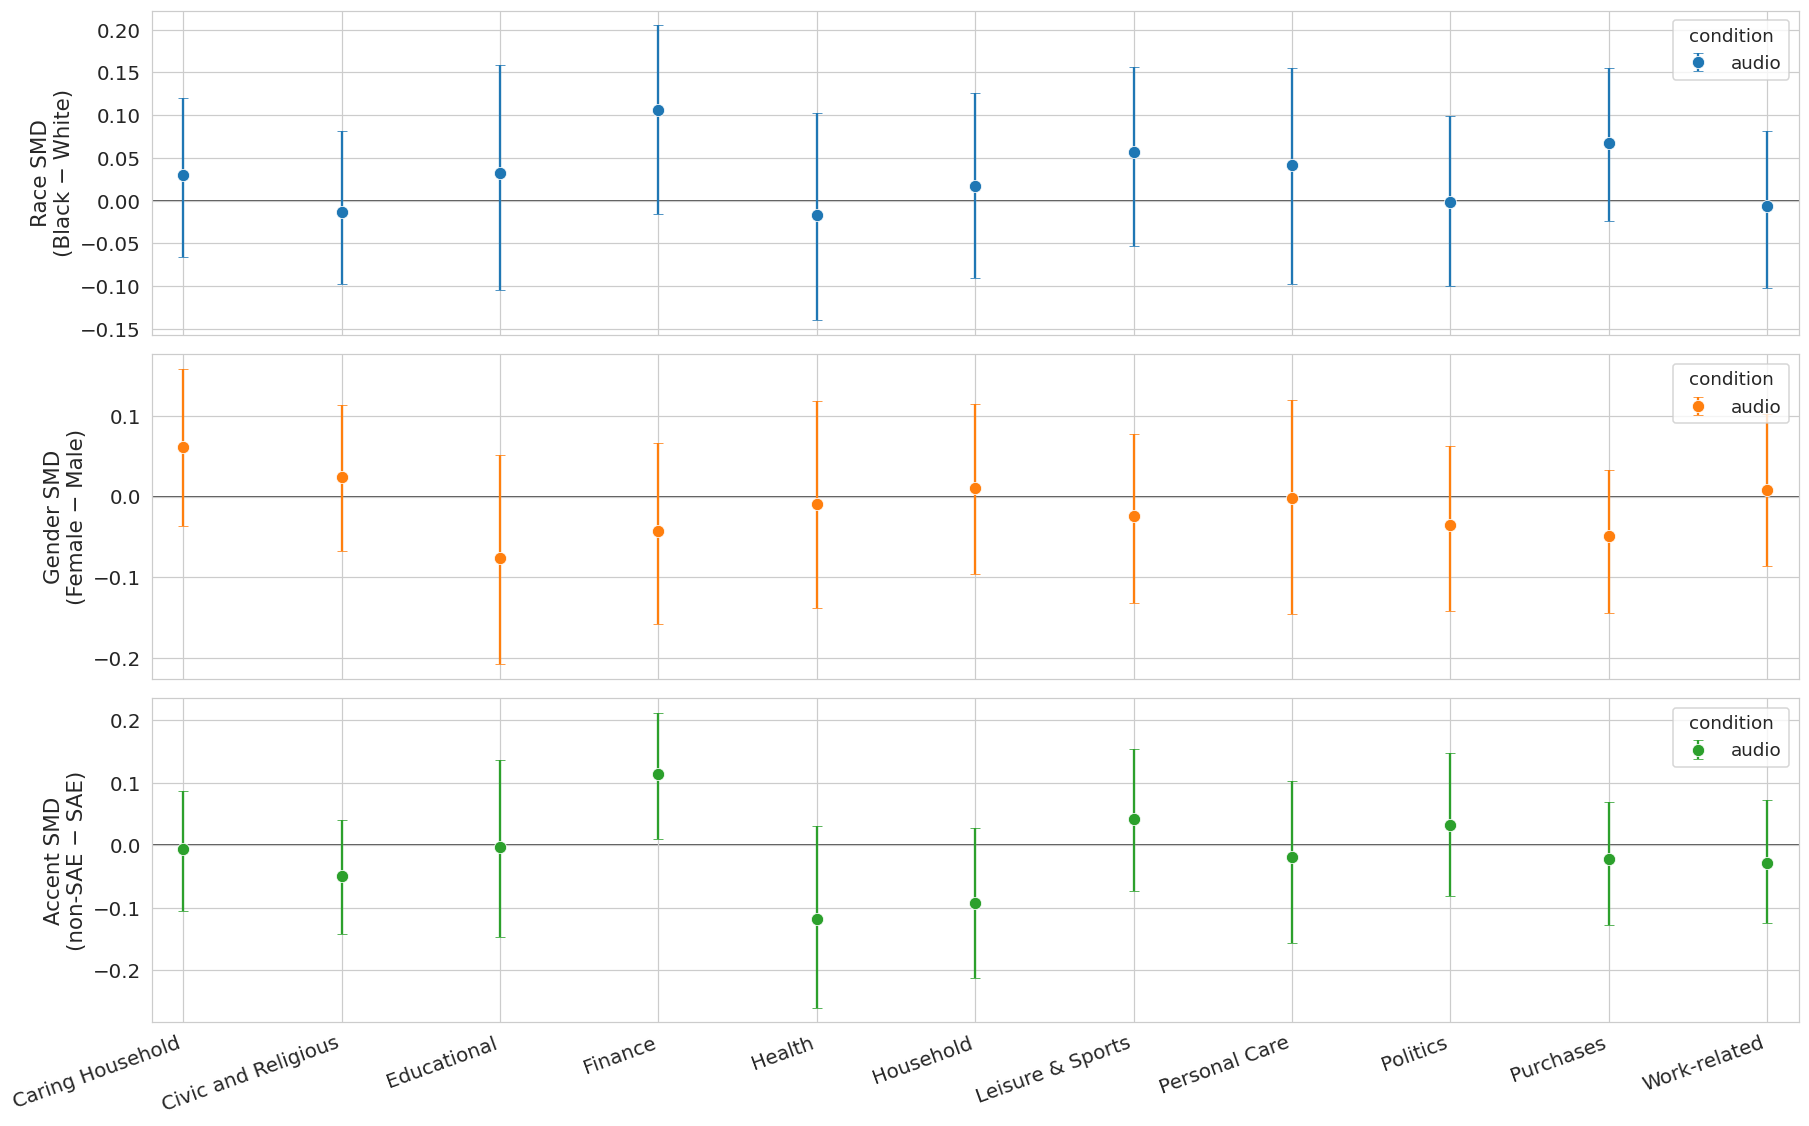

--- combined conditions: Qwen2.5-Omni-7B ---


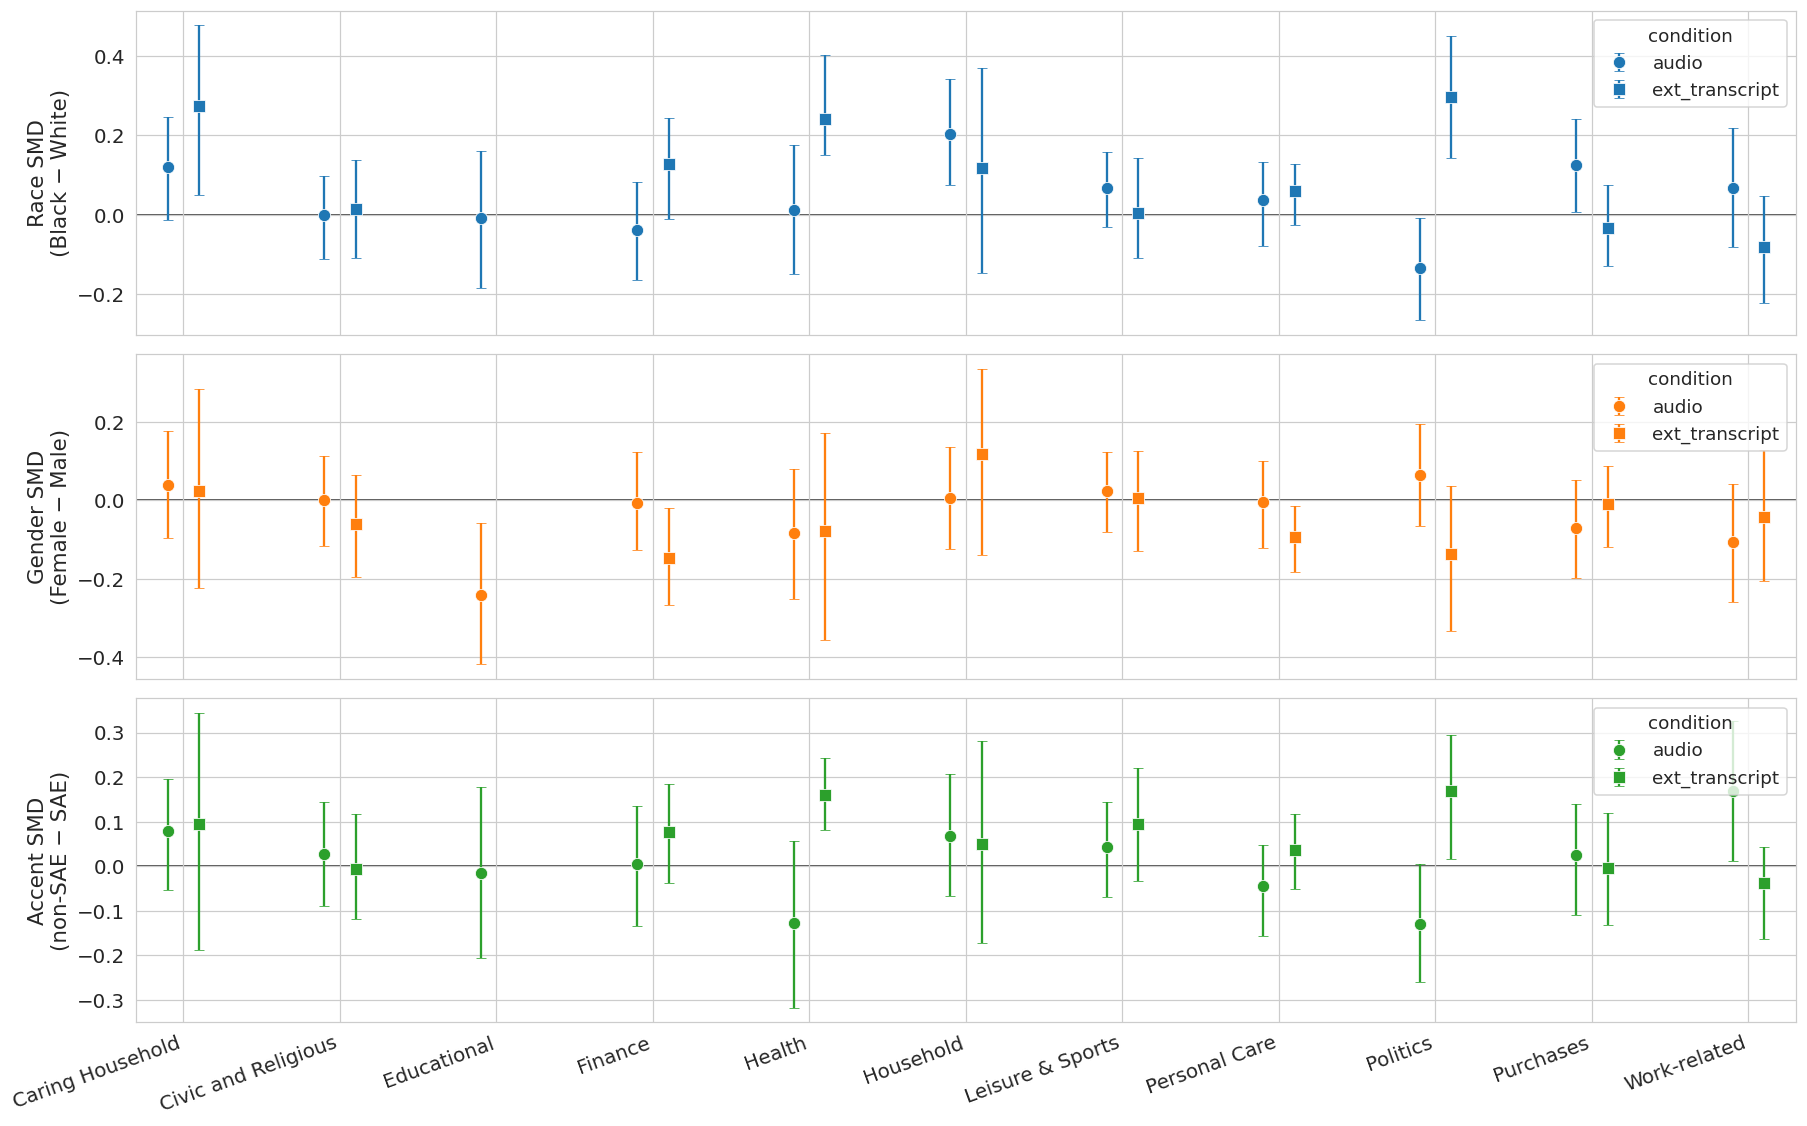

In [7]:
def plot_combined_conditions(sc_df, model_id, winsorize_pct,
                              axes_order=MAIN_AXES,
                              save_dir=SMD_DIR, show=True,
                              extra_suffix=""):
    """One row per axis in `axes_order`; one marker per condition the model ran."""
    wmask = sc_df["winsorize_pct"].isna() if winsorize_pct is None else (sc_df["winsorize_pct"] == winsorize_pct)
    msub = sc_df[wmask & (sc_df["model_id"] == model_id)]
    cond_scs = [(c, msub[msub["condition"] == c]) for c in CONDITION_MARKERS
                  if not msub[msub["condition"] == c].empty]
    if not cond_scs:
        return None

    scenarios = sorted({s for _, df_ in cond_scs for s in df_["scenario"].unique()})
    n_scen    = len(scenarios)
    n_axes    = len(axes_order)
    fig, axes = plt.subplots(n_axes, 1,
                                figsize=(max(WIDTH_MIN, WIDTH_PER_SCEN * n_scen + 4),
                                          3.2 * n_axes + 0.8),
                                sharex=True)
    if n_axes == 1:
        axes = [axes]
    x = np.arange(n_scen)
    # Tighter within-scenario jitter so adjacent conditions sit close.
    cj_half = 0.10 if len(cond_scs) <= 2 else 0.18
    jitters = np.linspace(-cj_half, cj_half, len(cond_scs)) if len(cond_scs) > 1 else [0.0]

    for ax, axis_name in zip(axes, axes_order):
        color = AXIS_STYLES[axis_name]["color"]
        for ci_, (cond, sc_) in enumerate(cond_scs):
            sub = sc_[sc_["axis"] == axis_name].set_index("scenario").reindex(scenarios)
            for i, scen in enumerate(scenarios):
                if scen not in sub.index or pd.isna(sub.loc[scen, "point"]):
                    continue
                row = sub.loc[scen]
                point = row["point"]; lo = row["ci_lo"]; hi = row["ci_hi"]
                err_lo = point - lo if pd.notna(lo) else 0.0
                err_hi = hi - point if pd.notna(hi) else 0.0
                ax.errorbar([x[i] + jitters[ci_]], [point],
                              yerr=[[err_lo], [err_hi]],
                              fmt=CONDITION_MARKERS[cond], color=color, ecolor=color,
                              markerfacecolor=color, markersize=8.0,
                              markeredgecolor="white", markeredgewidth=0.5,
                              capsize=3.0,
                              label=CONDITION_LABELS[cond] if i == 0 else None)
        _zero_line(ax)
        ax.set_ylabel(f"{AXIS_STYLES[axis_name]['label']} SMD\n({AXIS_STYLES[axis_name]['sign']})")
        ax.legend(loc="upper right", frameon=True, title="condition")
        ax.margins(x=0.02)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels([_short(s) for s in scenarios], rotation=20, ha="right")
    fig.tight_layout()
    if save_dir is not None:
        safe_m = model_id.replace("/", "_").replace(":", "_")
        wstem  = "raw" if winsorize_pct is None else f"wins{int(winsorize_pct * 100)}"
        stem   = f"{safe_m}__combined_conditions__{wstem}{_accent_suffix(axes_order)}{extra_suffix}"
        fig.savefig(save_dir / f"{stem}.png")
        fig.savefig(save_dir / f"{stem}.pdf")
    if show:  plt.show()
    else:     plt.close(fig)
    return fig


for axes_choice in (MAIN_AXES, AXES_ORDER):
    label = "main (race+gender)" if axes_choice == MAIN_AXES else "with_accent (race+gender+accent)"
    print(f"\n=========== {label} ===========")
    for m in MODELS_ORDER:
        print(f"--- combined conditions: {_model_label(m)} ---")
        plot_combined_conditions(sc, m, 0.01, axes_order=axes_choice)

## 5. Per-prompt strip plot — one step before scenario aggregation

Faceted strip plot, one small subplot per scenario, showing the per-prompt (iter-averaged) SMDs as dots together with a horizontal line at the scenario point estimate. Useful for inspecting **whether a scenario being on one side is driven by one extreme prompt or is systematic across the prompts in that scenario**.


=========== main (race+gender) ===========
--- per-prompt strip: Gemini-3.1-flash-lite ---


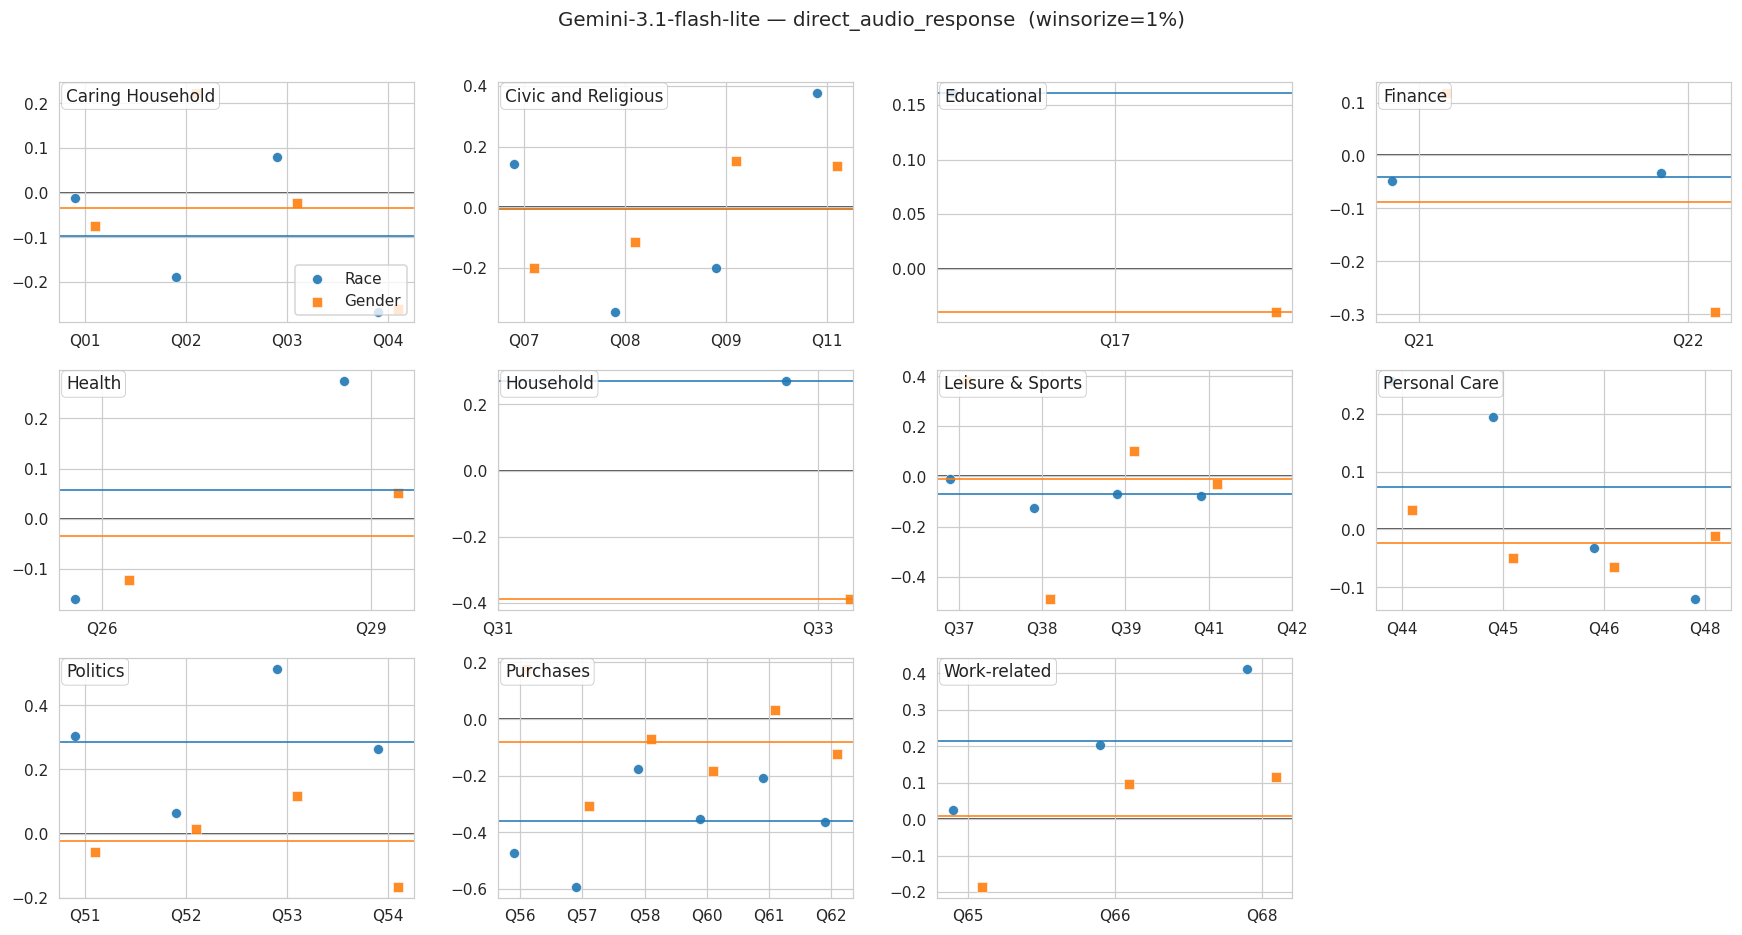

--- per-prompt strip: GPT-Audio-1.5 ---


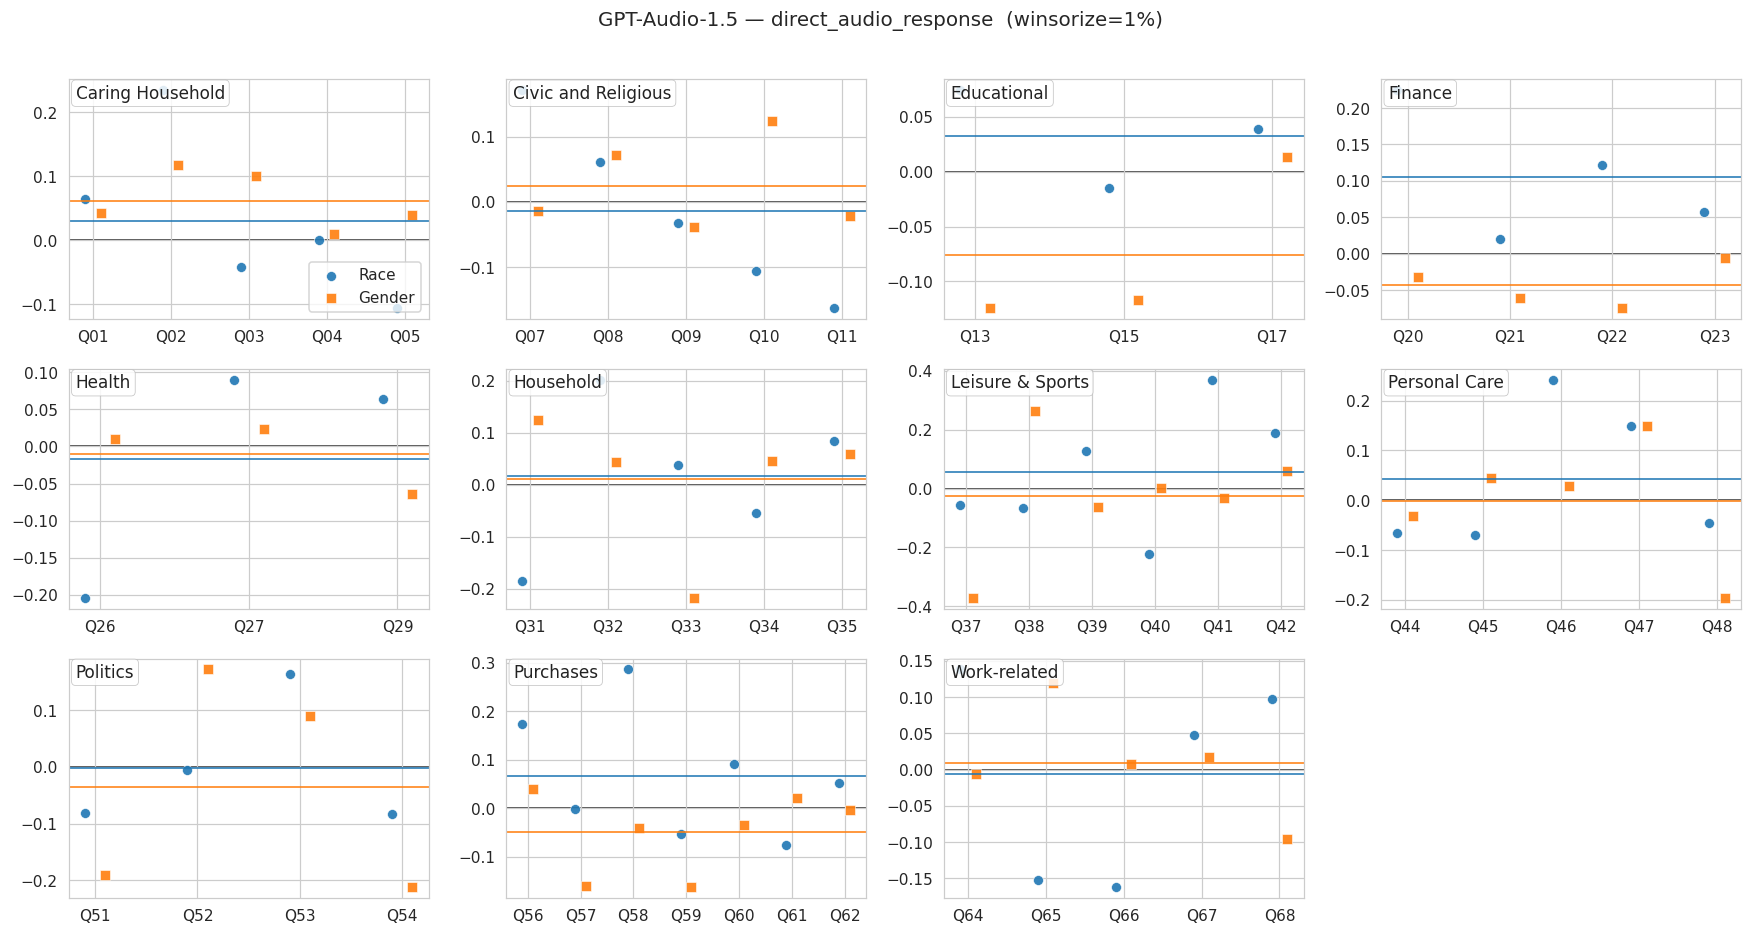

--- per-prompt strip: Qwen2.5-Omni-7B ---


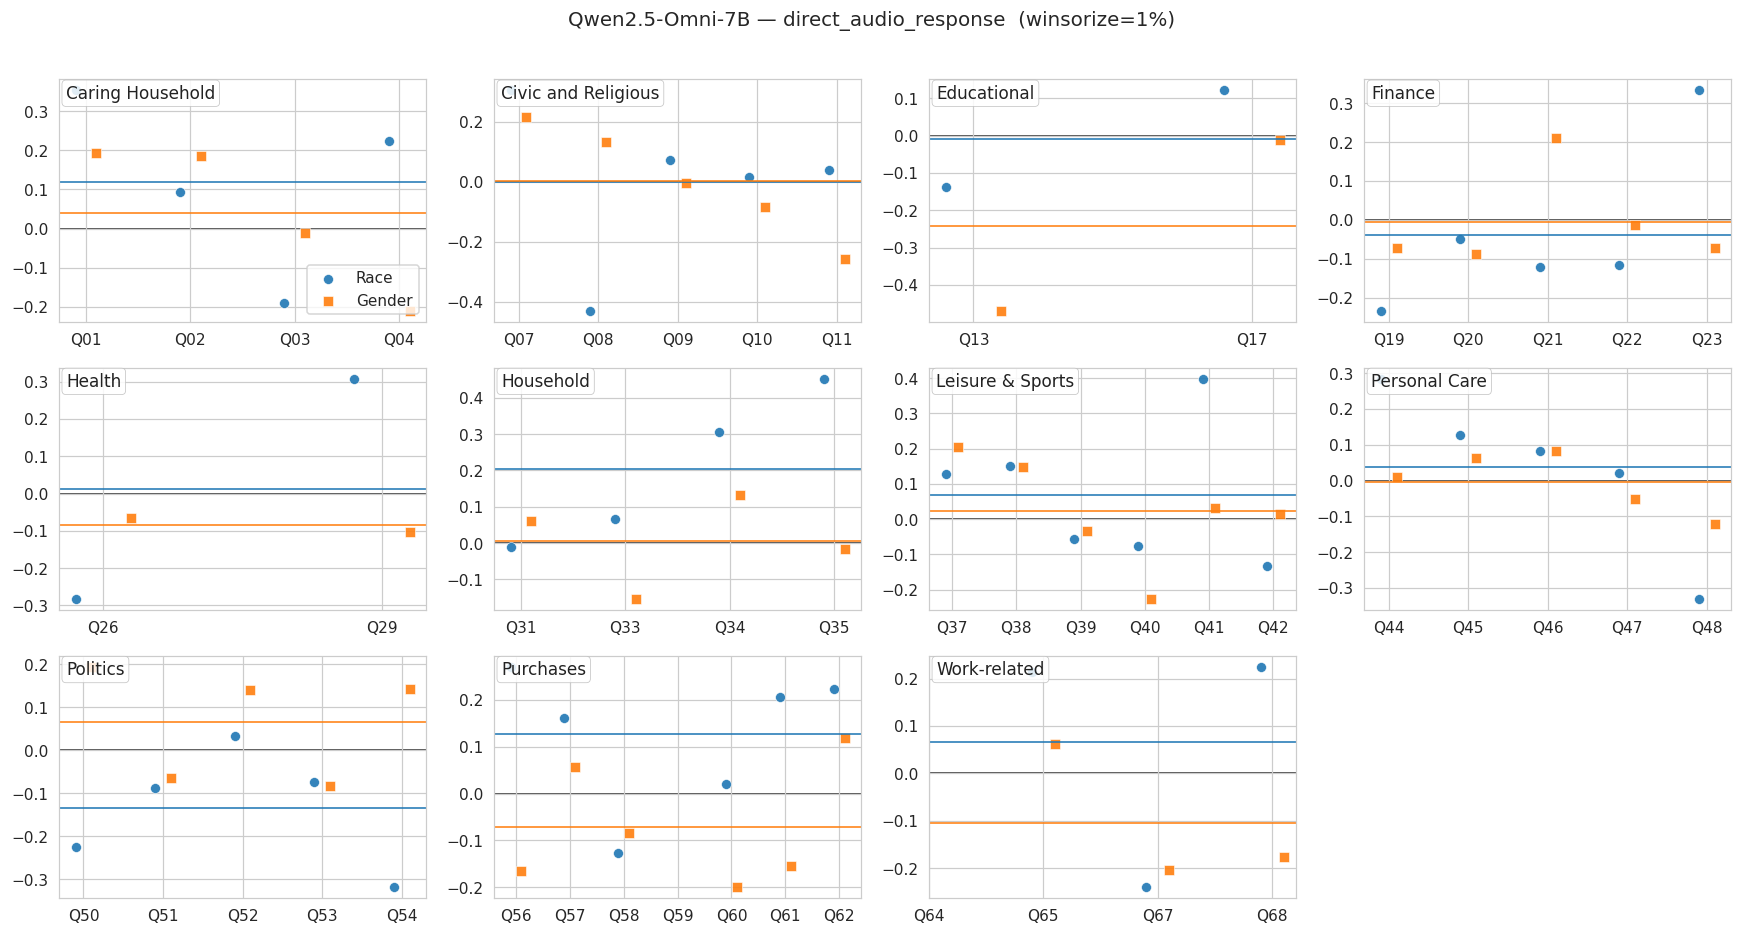


=========== with_accent (race+gender+accent) ===========
--- per-prompt strip: Gemini-3.1-flash-lite ---


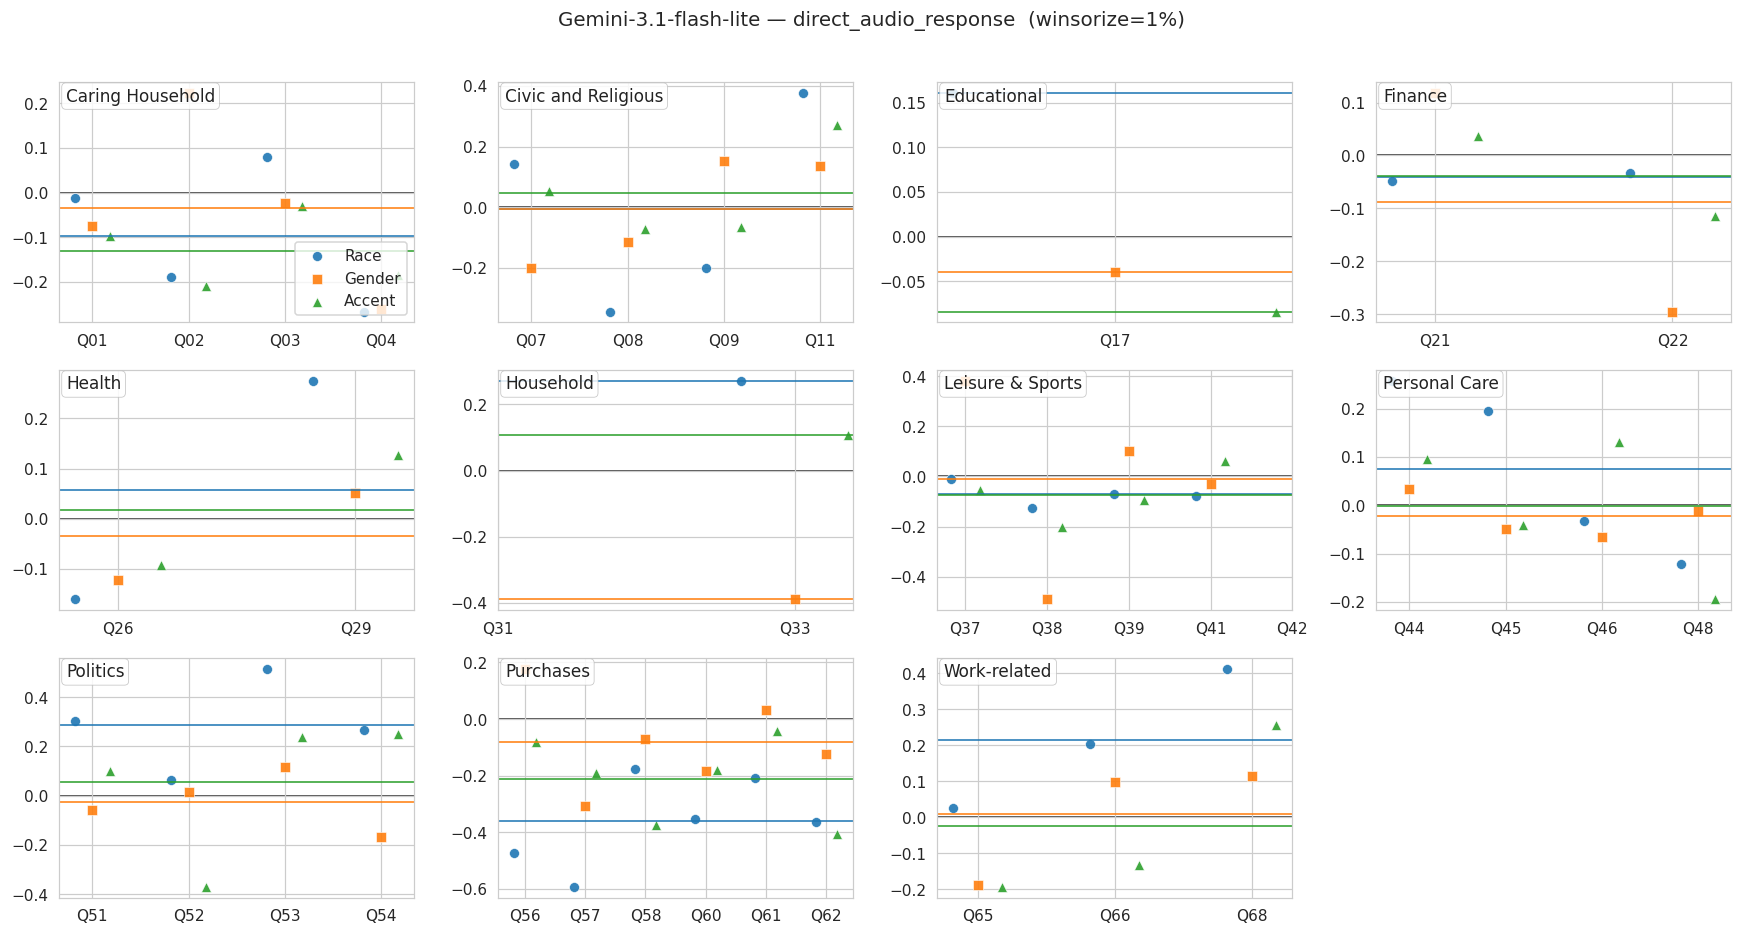

--- per-prompt strip: GPT-Audio-1.5 ---


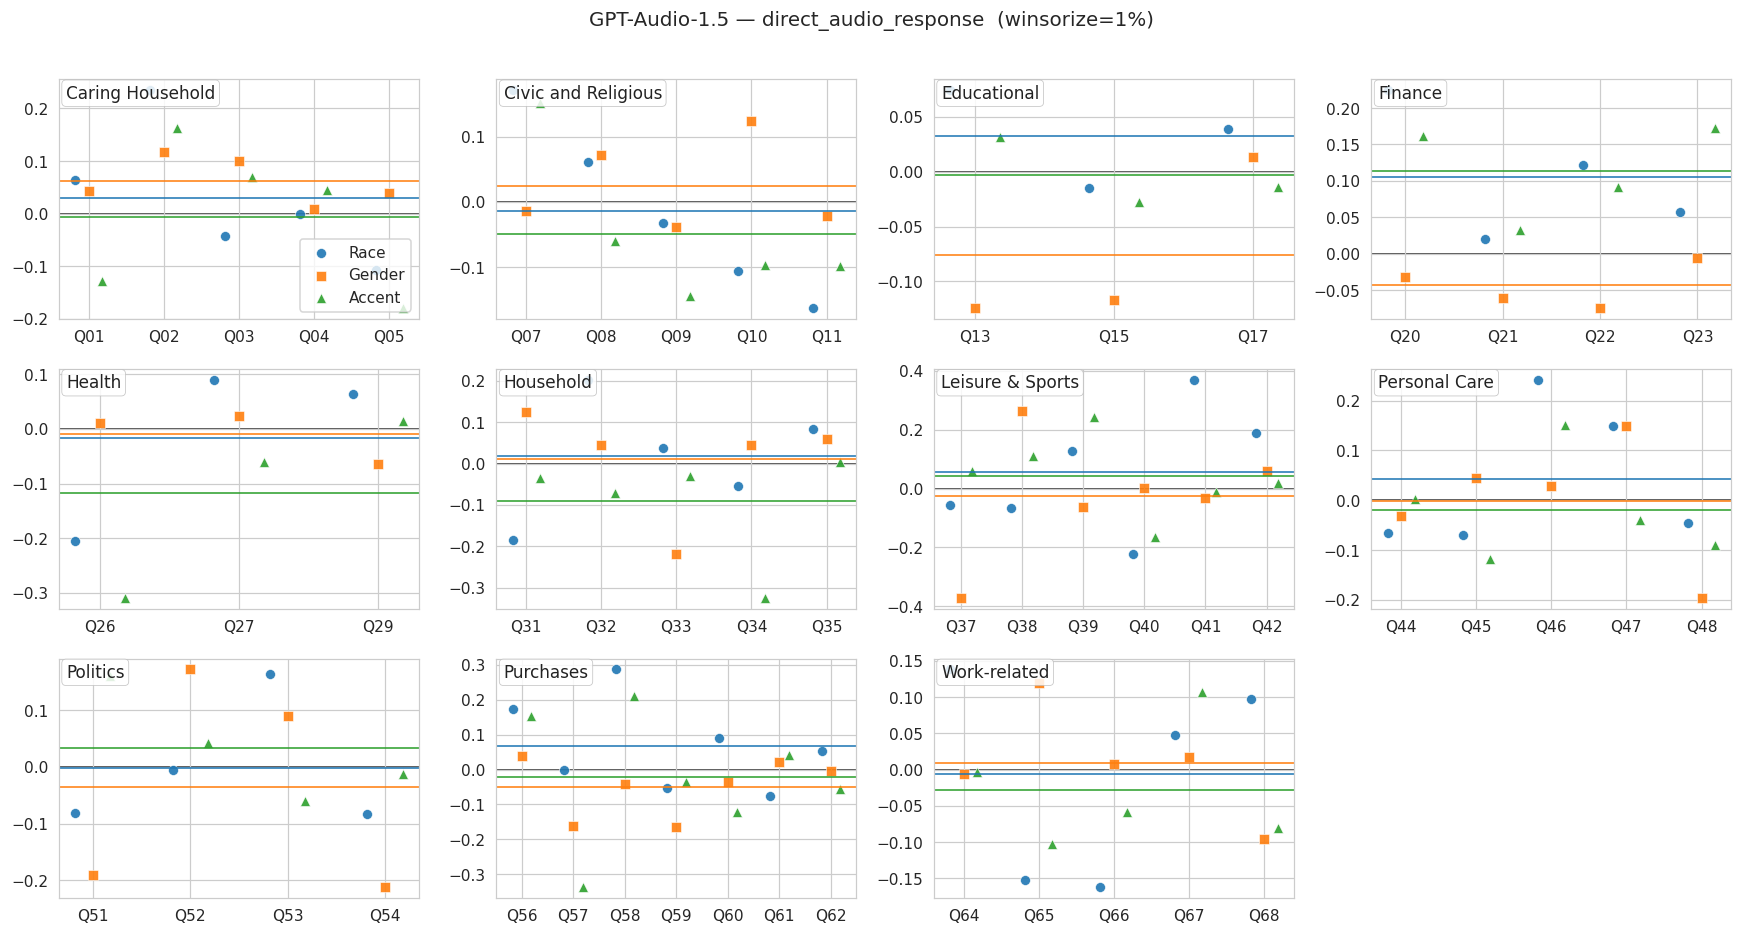

--- per-prompt strip: Qwen2.5-Omni-7B ---


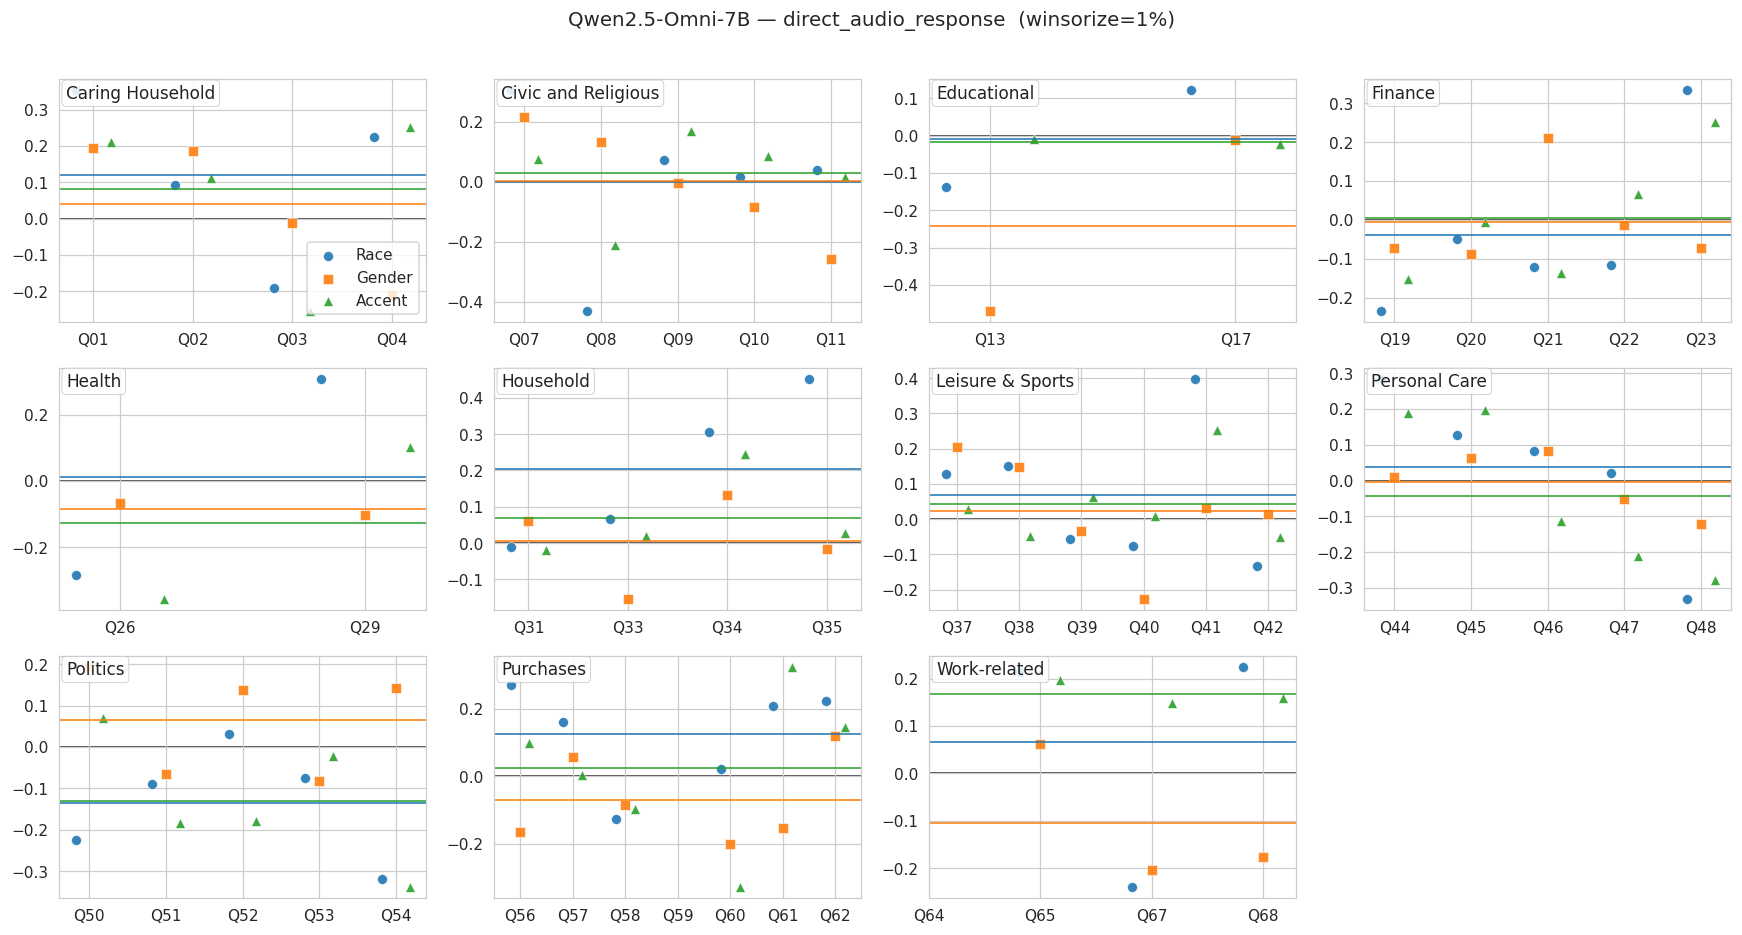

In [8]:
def plot_per_prompt_strip(prompt_df, scenario_df, model_id, condition, winsorize_pct,
                            axes_order=MAIN_AXES,
                            save_dir=SMD_STRIP_DIR, show=True, n_cols=4,
                            extra_suffix=""):
    """Faceted strip plot of per-prompt SMDs (one dot per axis × prompt) with
    horizontal lines at the scenario point estimates. One subplot per scenario."""
    wmask_p = prompt_df["winsorize_pct"].isna() if winsorize_pct is None else (prompt_df["winsorize_pct"] == winsorize_pct)
    wmask_s = scenario_df["winsorize_pct"].isna() if winsorize_pct is None else (scenario_df["winsorize_pct"] == winsorize_pct)
    pp     = prompt_df[wmask_p & (prompt_df["model_id"] == model_id) & (prompt_df["condition"] == condition)].copy()
    sc_df  = scenario_df[wmask_s & (scenario_df["model_id"] == model_id) & (scenario_df["condition"] == condition)].copy()
    if pp.empty or sc_df.empty:
        return None

    scenarios = sorted(sc_df["scenario"].unique())
    n_scen    = len(scenarios)
    n_rows    = int(np.ceil(n_scen / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                                figsize=(4.0 * n_cols, 2.8 * n_rows),
                                squeeze=False)
    offsets = _axis_offsets(len(axes_order), half_width=(0.10 if len(axes_order) <= 2 else 0.18))

    for k, scen in enumerate(scenarios):
        r, c = divmod(k, n_cols)
        ax   = axes[r, c]
        prompts_in = pp[pp["scenario"] == scen].sort_values("question_id").copy()
        qids = prompts_in["question_id"].tolist()
        x    = np.arange(len(qids))

        for axis_name, dx in zip(axes_order, offsets):
            style = AXIS_STYLES[axis_name]
            col = f"smd_{axis_name}"
            if col not in prompts_in.columns:
                continue
            ax.scatter(x + dx, prompts_in[col],
                        color=style["color"], marker=style["marker"], s=42, alpha=0.9,
                        edgecolor="white", linewidth=0.4, label=style["label"])

        scen_rows = sc_df[sc_df["scenario"] == scen].set_index("axis")
        for axis_name in axes_order:
            if axis_name in scen_rows.index and pd.notna(scen_rows.loc[axis_name, "point"]):
                ax.axhline(scen_rows.loc[axis_name, "point"],
                            color=AXIS_STYLES[axis_name]["color"],
                            linestyle="-", linewidth=1.2, alpha=0.85)

        _zero_line(ax)
        ax.set_xticks(x)
        ax.set_xticklabels([f"Q{int(q):02d}" for q in qids], rotation=0, fontsize=10)
        ax.tick_params(axis="y", labelsize=10)
        ax.text(0.02, 0.98, _short(scen),
                  transform=ax.transAxes, ha="left", va="top",
                  fontsize=11, color="#222",
                  bbox=dict(boxstyle="round,pad=0.25",
                            facecolor="white", edgecolor="#bbb",
                            linewidth=0.5, alpha=0.85))
        if r == 0 and c == 0:
            ax.legend(loc="lower right", fontsize=10, frameon=True)

    for k in range(n_scen, n_rows * n_cols):
        r, c = divmod(k, n_cols)
        axes[r, c].set_visible(False)

    fig.suptitle(f"{_model_label(model_id)} — {condition}  (winsorize={'raw' if winsorize_pct is None else '1%'})",
                  fontsize=13, y=1.01)
    fig.tight_layout()
    if save_dir is not None:
        safe_m = model_id.replace("/", "_").replace(":", "_")
        wstem  = "raw" if winsorize_pct is None else f"wins{int(winsorize_pct * 100)}"
        stem   = f"{safe_m}__{condition}__per_prompt_strip__{wstem}{_accent_suffix(axes_order)}{extra_suffix}"
        fig.savefig(save_dir / f"{stem}.png")
        fig.savefig(save_dir / f"{stem}.pdf")
    if show:  plt.show()
    else:     plt.close(fig)
    return fig


# One per-prompt strip plot per model for the headline (direct_audio × wins1) configuration,
# rendered for both axes choices.
for axes_choice in (MAIN_AXES, AXES_ORDER):
    label = "main (race+gender)" if axes_choice == MAIN_AXES else "with_accent (race+gender+accent)"
    print(f"\n=========== {label} ===========")
    for m in MODELS_ORDER:
        print(f"--- per-prompt strip: {_model_label(m)} ---")
        plot_per_prompt_strip(prompts, sc, m, "direct_audio_response", 0.01,
                                axes_order=axes_choice)

## 5b. Appendix figures — direction-aware aggregation (`direction_clear = 1`)

Companion figures to the headline plots above, generated from the appendix outputs of notebook 07 § 7b:

- `data/model_outputs/disparity/scenario_smds_with_ci__direction_clear.csv` — bootstrap CIs over the 26 prompts that survived BP exclusion within the `direction_clear = 1` set, with SMDs sign-unified so that **negative SMD = harmful direction for the minority group** uniformly across the subset.
- `data/model_outputs/disparity/prompt_level_smds__direction_clear.csv` — per-prompt SMDs with the same sign convention.

Same plotting primitives as § 1-5 above. Each figure inherits the same filename stem and adds an `__direction_clear` suffix. Read these as the directionally-coded view: a marker below the zero line is the harmful direction.


In [9]:
# Load the direction-aware appendix outputs (written by notebook 07 § 7b).
sc_dc      = pd.read_csv(DISP / "scenario_smds_with_ci__direction_clear.csv")
prompts_dc = pd.read_csv(DISP / "prompt_level_smds__direction_clear.csv")
print(f"scenario_smds_with_ci__direction_clear: {len(sc_dc)} rows")
print(f"prompt_level_smds__direction_clear   : {len(prompts_dc)} rows")
print("\nappendix coverage (model × condition × winsorize):")
print(sc_dc.groupby(["model_id", "condition", "winsorize_pct"]).size().to_string())


scenario_smds_with_ci__direction_clear: 288 rows
prompt_level_smds__direction_clear   : 264 rows

appendix coverage (model × condition × winsorize):
model_id                       condition                     winsorize_pct
Qwen/Qwen2.5-Omni-7B           direct_audio_response         0.01             24
                               external_transcript_response  0.01             24
gemini-3.1-flash-lite-preview  direct_audio_response         0.01             21
                               external_transcript_response  0.01             24
                               self_transcript_response      0.01             24
gpt-audio-1.5                  direct_audio_response         0.01             27


In [10]:
# Appendix: per-(model × condition × winsorize) figures over the direction-aware subset.
n_app = 0
for axes_choice in (MAIN_AXES, AXES_ORDER):
    for w in [None, 0.01]:
        for cond in sorted(sc_dc["condition"].unique()):
            for m in sorted(sc_dc.loc[sc_dc["condition"] == cond, "model_id"].unique()):
                sub = sc_dc[(sc_dc["model_id"] == m) & (sc_dc["condition"] == cond)
                            & ((sc_dc["winsorize_pct"] == w) if w is not None else sc_dc["winsorize_pct"].isna())]
                if sub.empty:
                    continue
                plot_scenario_smds(sub, m, cond, w, axes_order=axes_choice,
                                    save_dir=SMD_DIR, show=False,
                                    extra_suffix="__direction_clear")
                n_app += 1
print(f"rendered {n_app} appendix per-(model × condition × winsorize) figures into {SMD_DIR.relative_to(REPO_ROOT)}/")


rendered 24 appendix per-(model × condition × winsorize) figures into paper/figures/smd/


--- appendix main (race + gender) ---


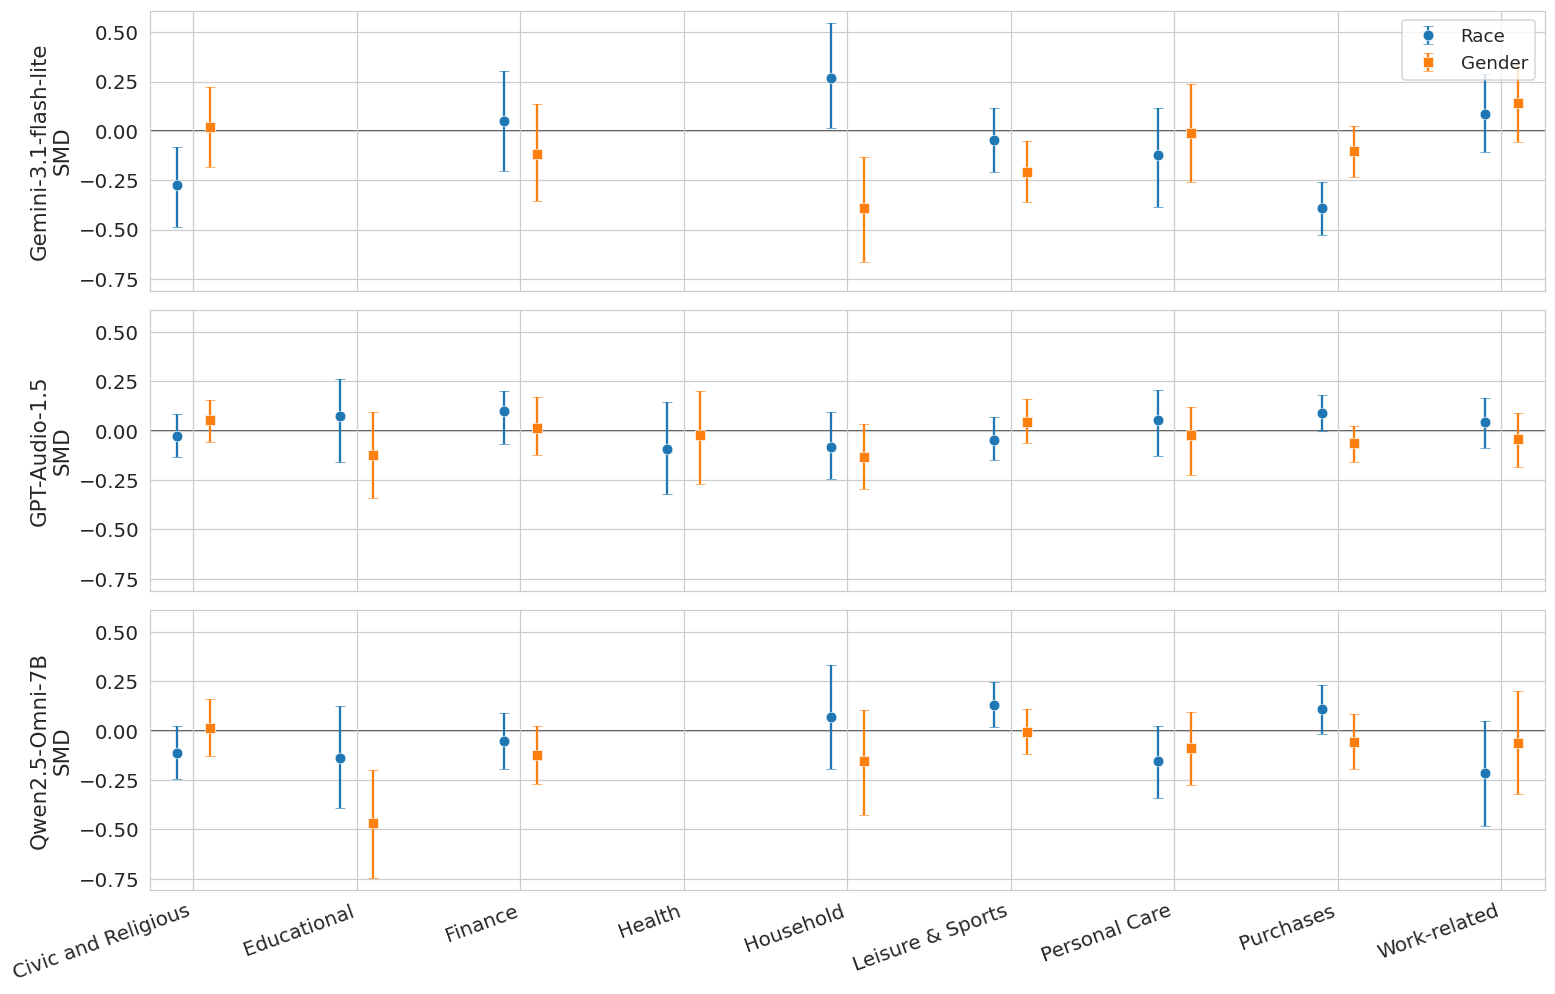

--- appendix with_accent (race + gender + accent) ---


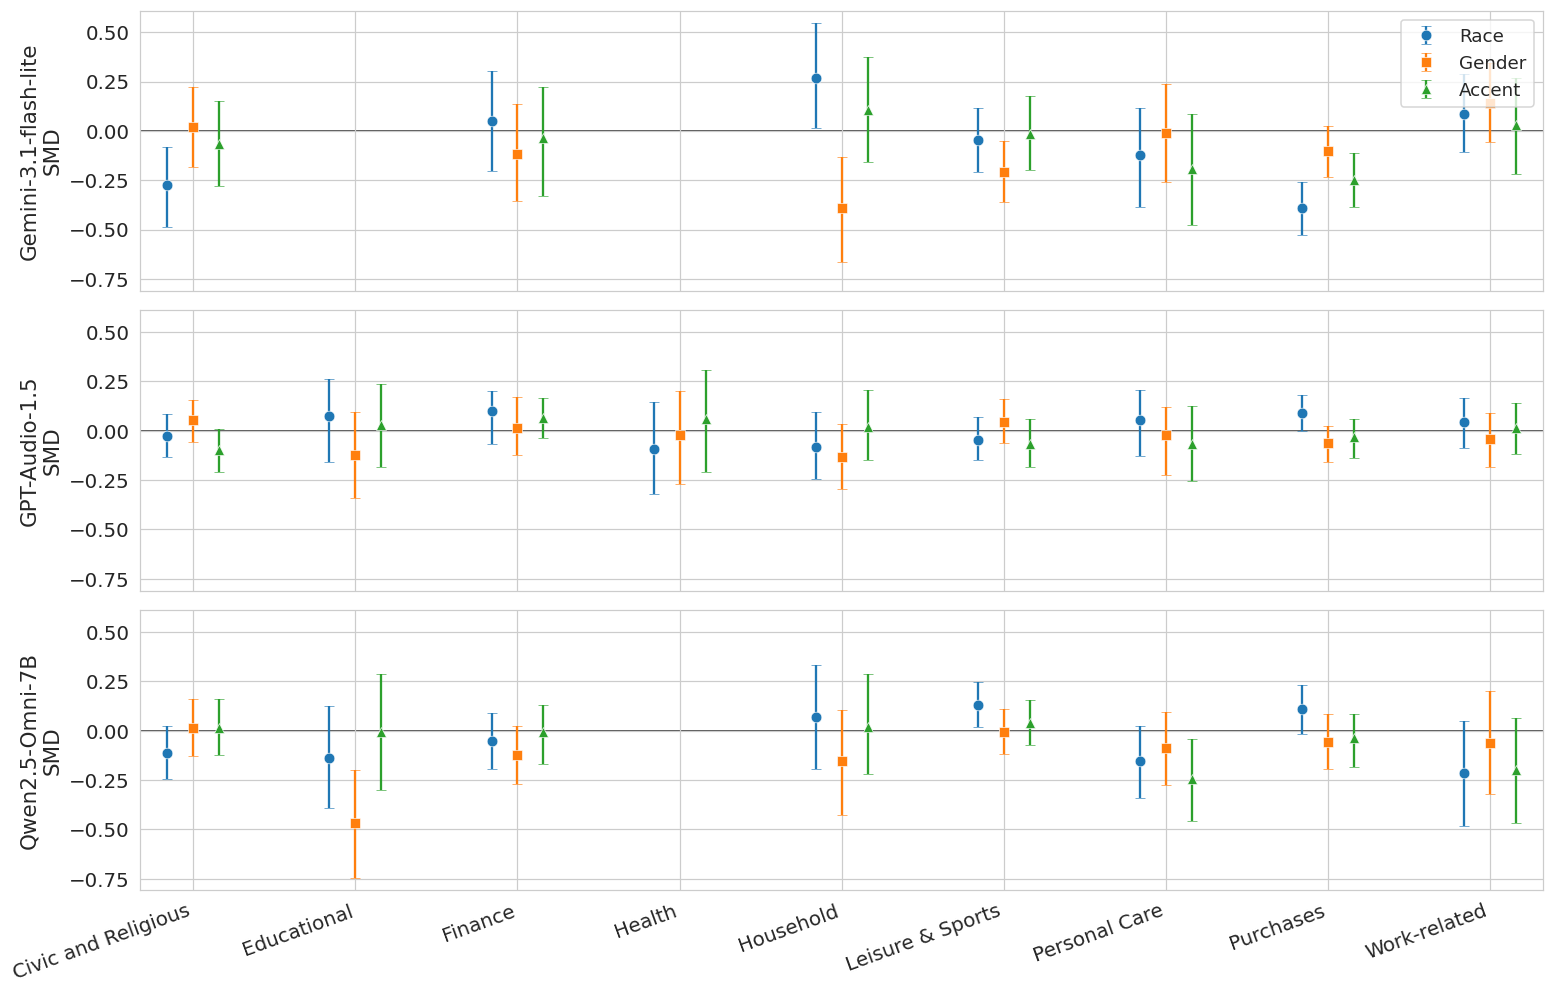

In [11]:
# Appendix headline: three-model stacked plot, direct_audio × wins1 (both axes choices).
print("--- appendix main (race + gender) ---")
_ = plot_models_stacked(sc_dc, condition="direct_audio_response", winsorize_pct=0.01,
                          axes_order=MAIN_AXES, extra_suffix="__direction_clear")
print("--- appendix with_accent (race + gender + accent) ---")
_ = plot_models_stacked(sc_dc, condition="direct_audio_response", winsorize_pct=0.01,
                          axes_order=AXES_ORDER, extra_suffix="__direction_clear")



=========== APPENDIX main (race+gender) ===========

--- direct_audio_response (winsorize=raw) ---


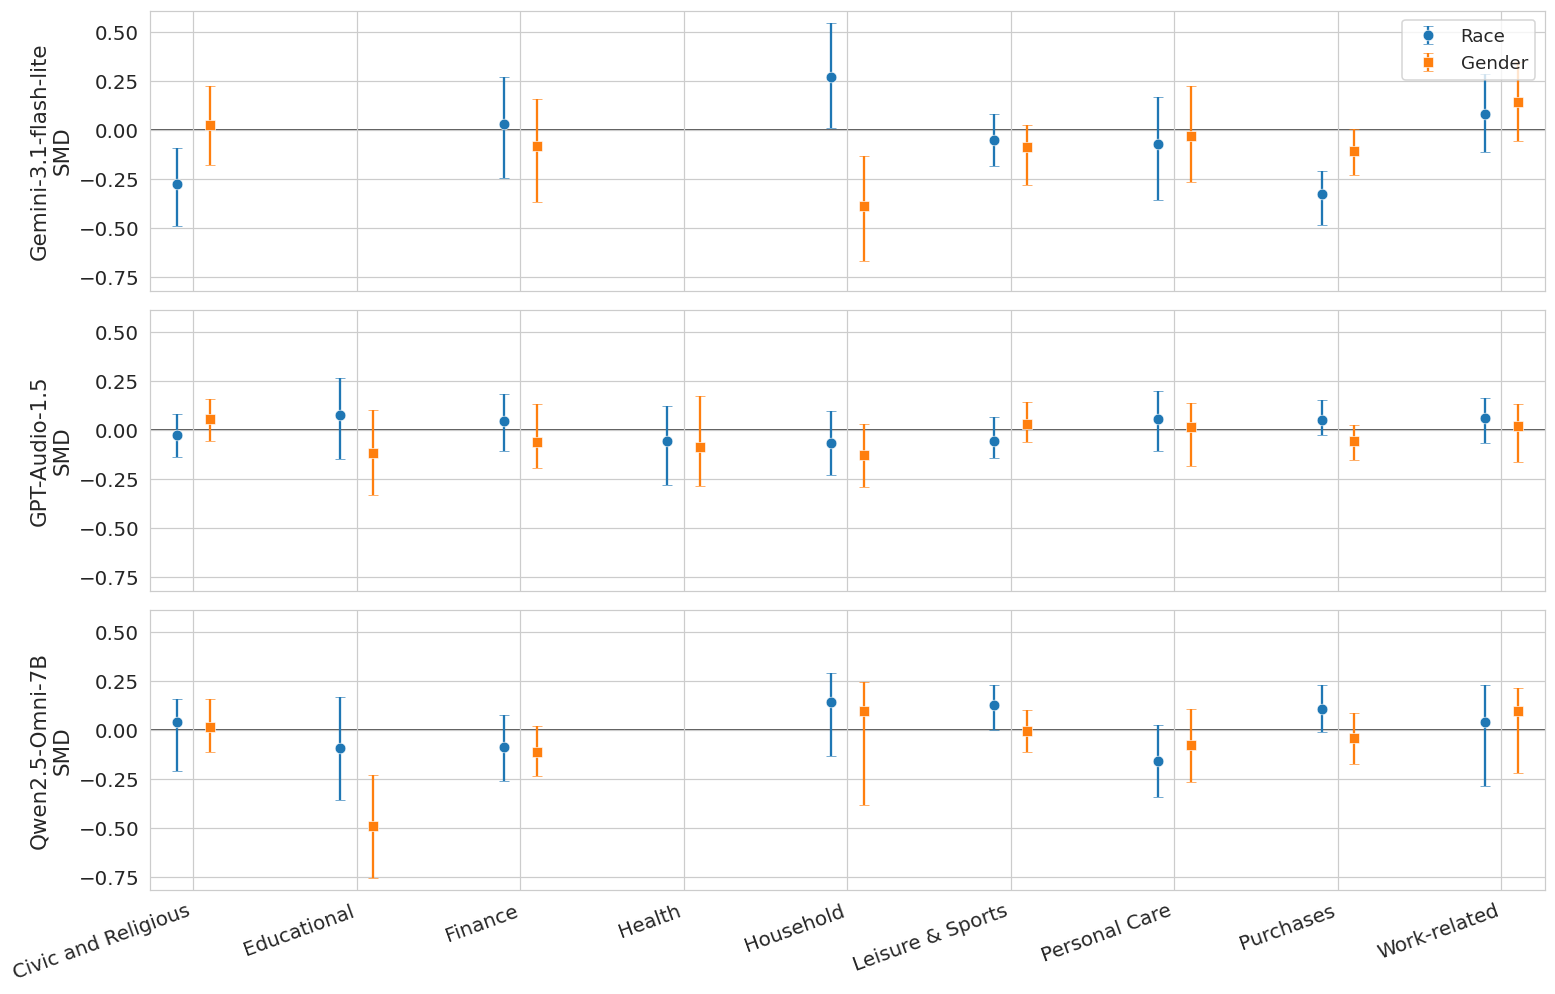


--- external_transcript_response (winsorize=1%) ---


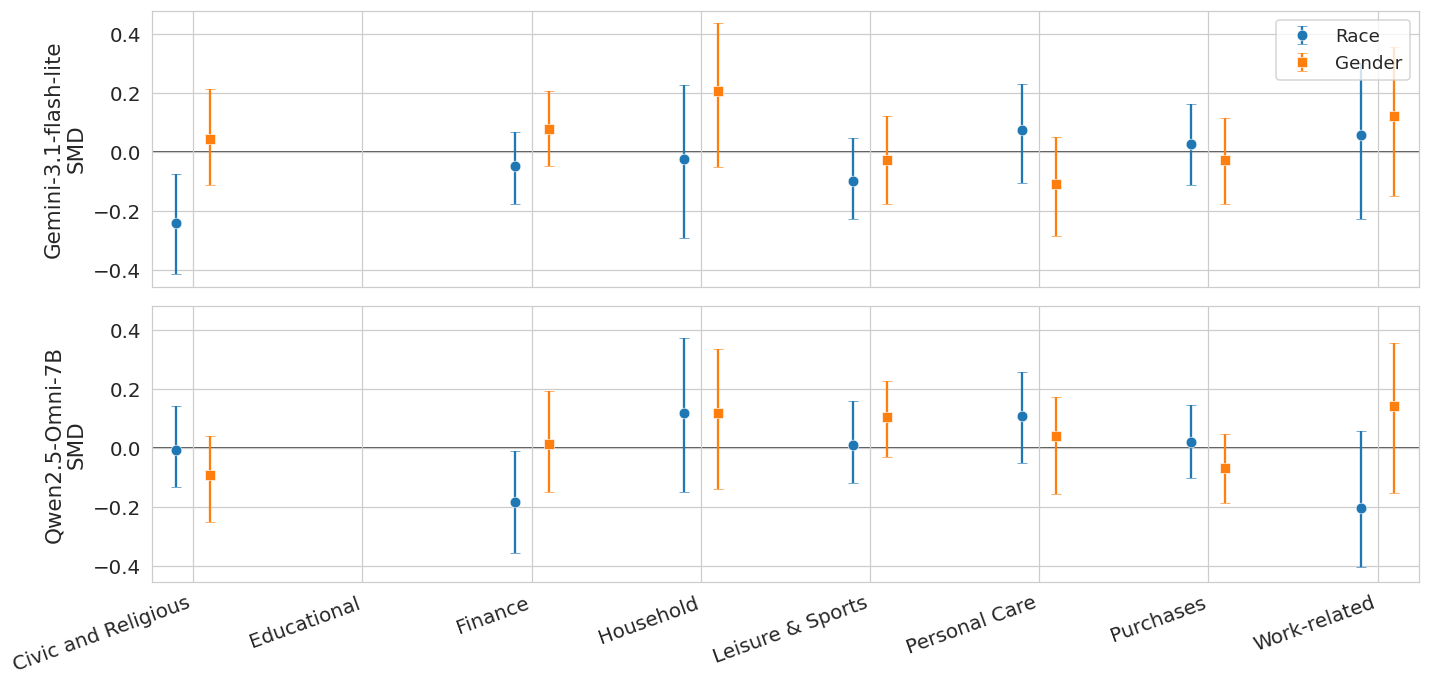


--- self_transcript_response (winsorize=1%) ---


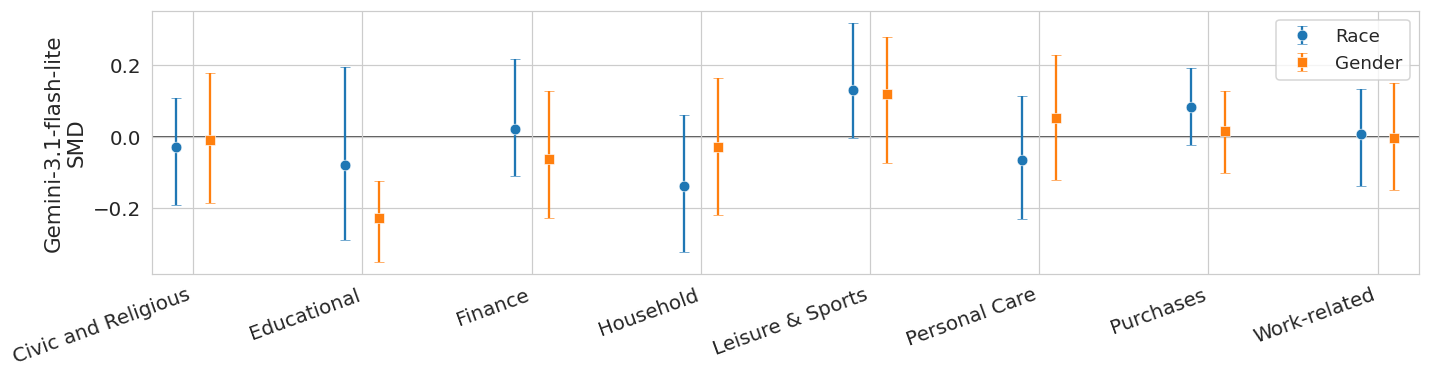


=========== APPENDIX with_accent (race+gender+accent) ===========

--- direct_audio_response (winsorize=raw) ---


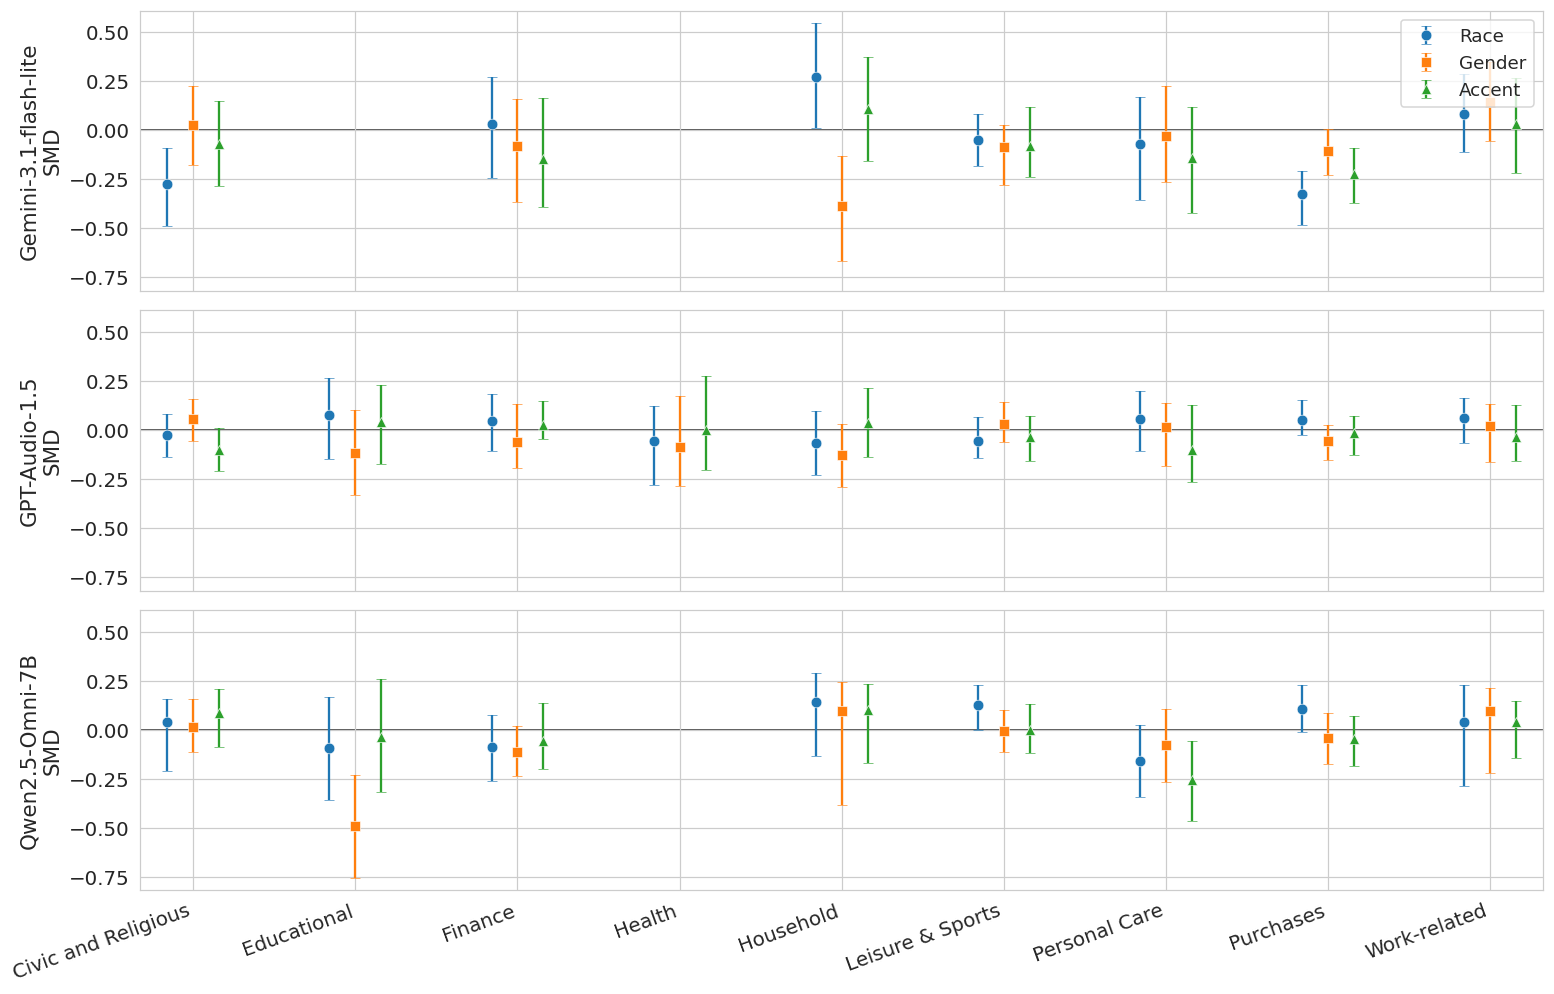


--- external_transcript_response (winsorize=1%) ---


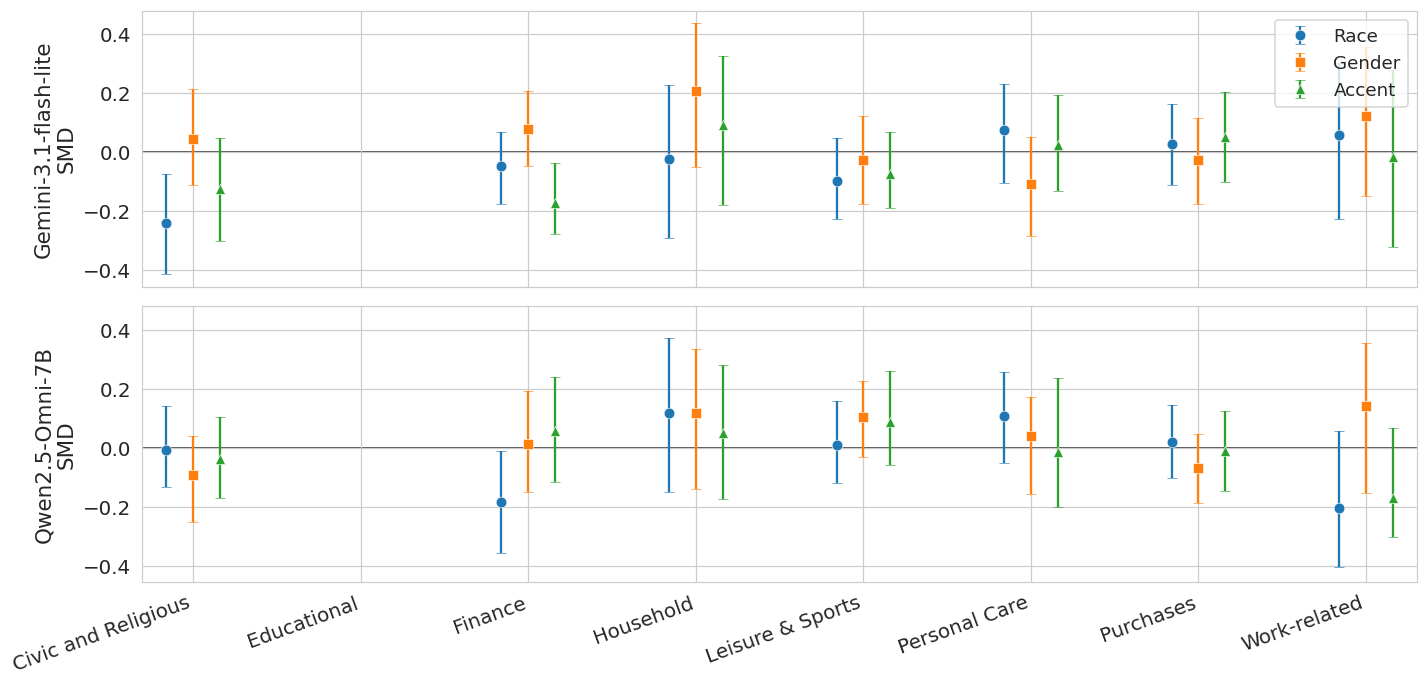


--- self_transcript_response (winsorize=1%) ---


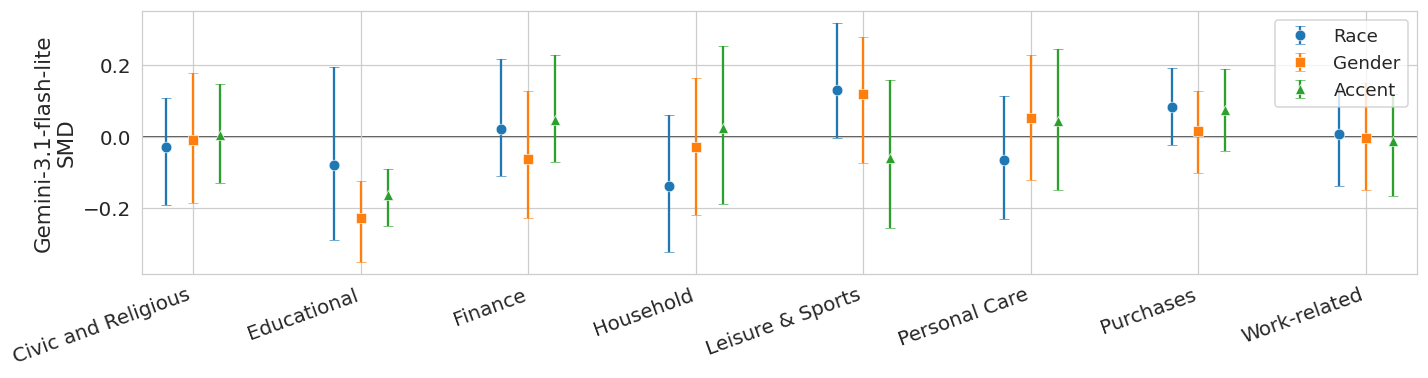

In [12]:
# Appendix variants — raw winsorize on direct_audio + the two transcript conditions.
for axes_choice in (MAIN_AXES, AXES_ORDER):
    label = "main (race+gender)" if axes_choice == MAIN_AXES else "with_accent (race+gender+accent)"
    print(f"\n=========== APPENDIX {label} ===========")
    for cond, w in [
        ("direct_audio_response",         None),
        ("external_transcript_response", 0.01),
        ("self_transcript_response",     0.01),
    ]:
        print(f"\n--- {cond} (winsorize={'raw' if w is None else '1%'}) ---")
        plot_models_stacked(sc_dc, condition=cond, winsorize_pct=w,
                              axes_order=axes_choice, extra_suffix="__direction_clear")



=========== APPENDIX main (race+gender) ===========
--- combined conditions: Gemini-3.1-flash-lite ---


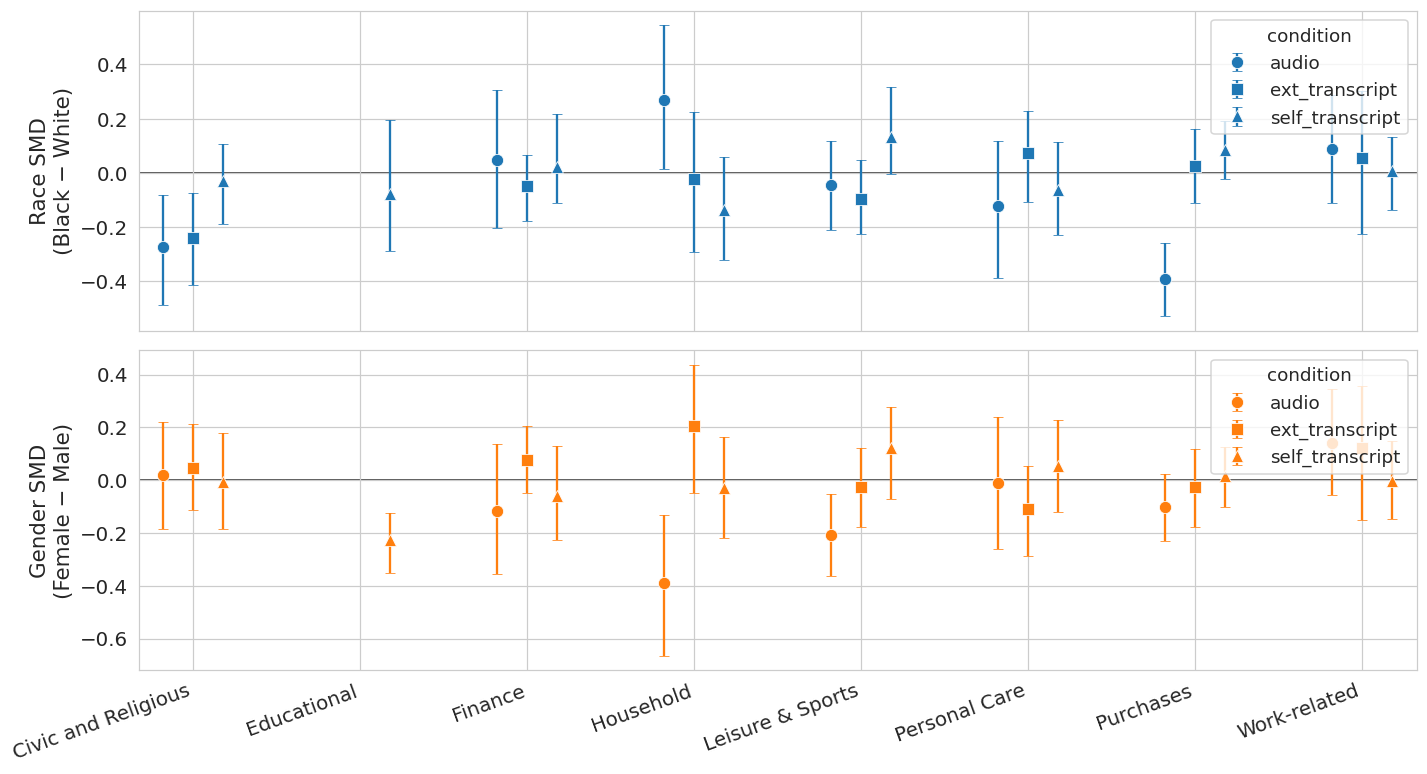

--- combined conditions: GPT-Audio-1.5 ---


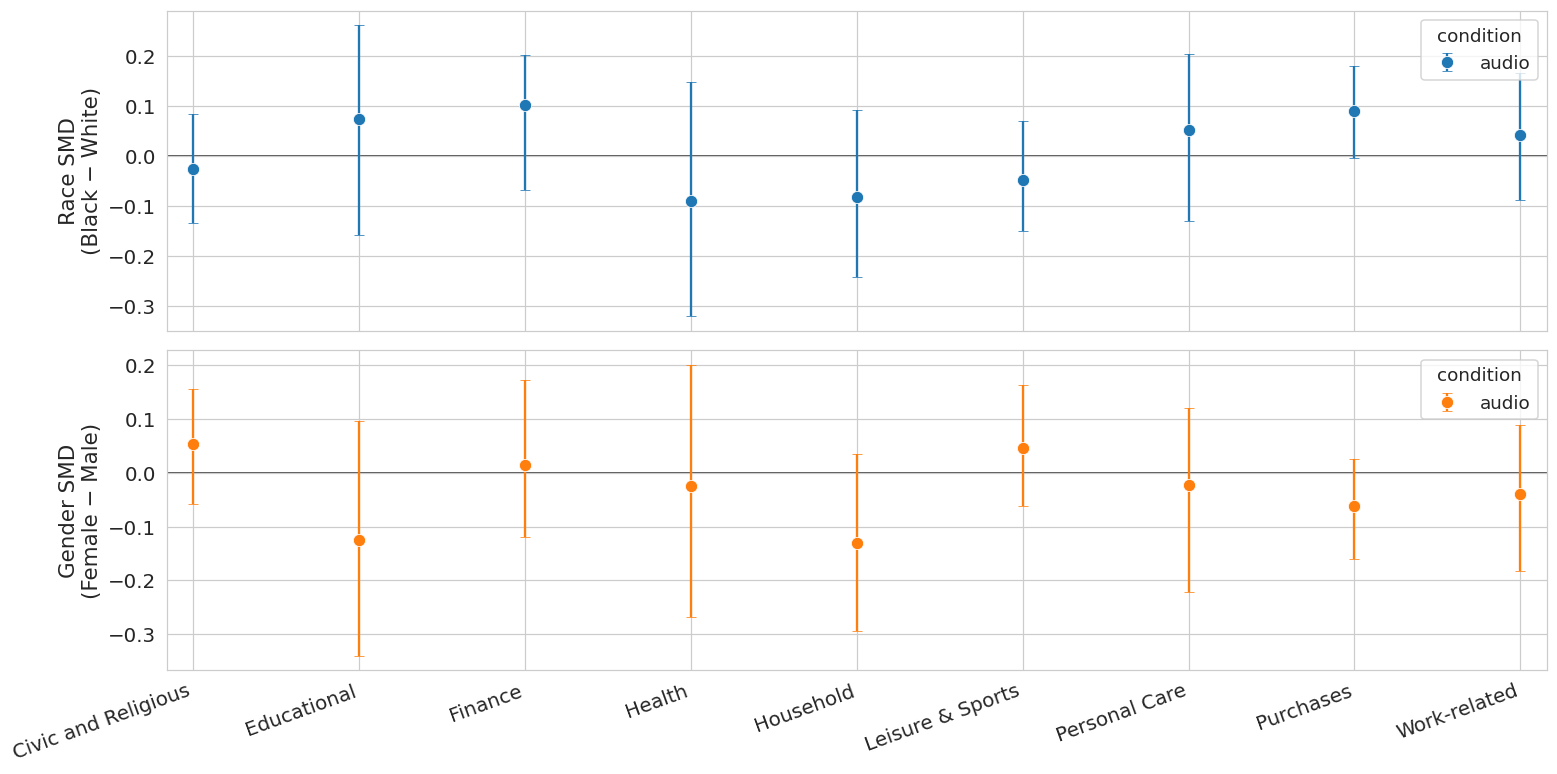

--- combined conditions: Qwen2.5-Omni-7B ---


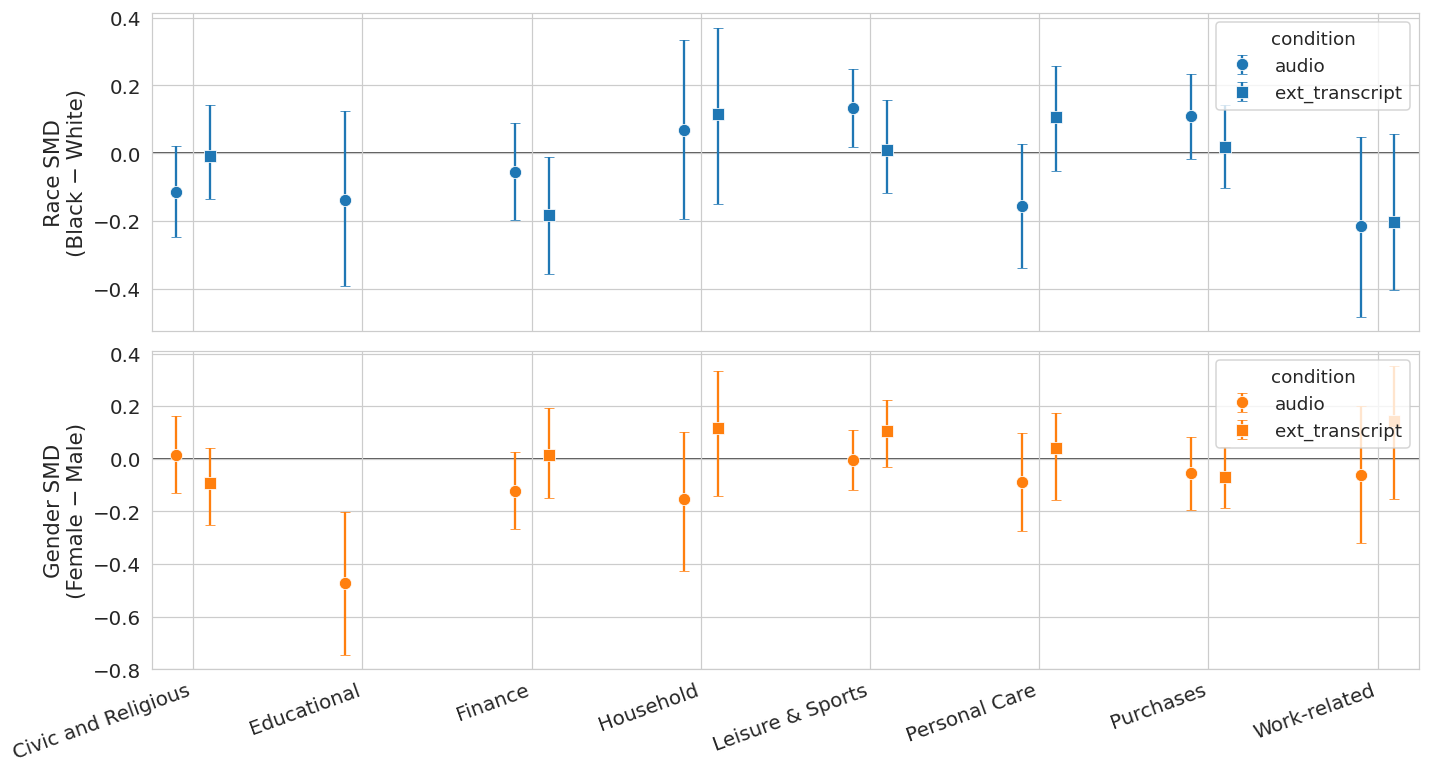


=========== APPENDIX with_accent (race+gender+accent) ===========
--- combined conditions: Gemini-3.1-flash-lite ---


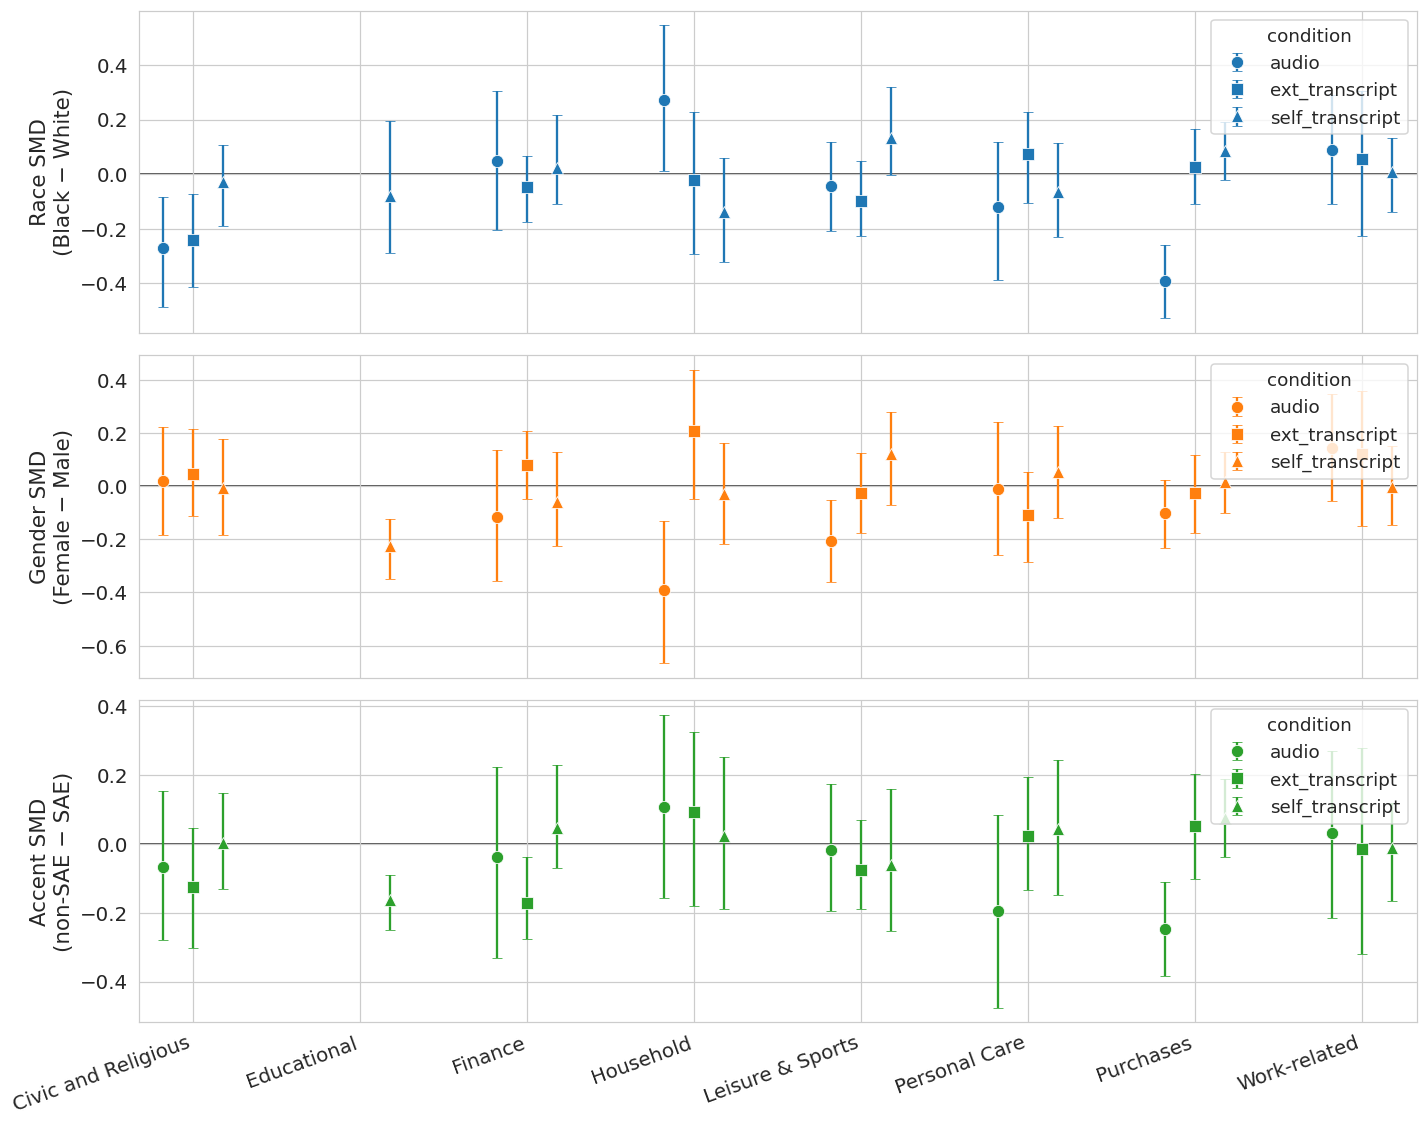

--- combined conditions: GPT-Audio-1.5 ---


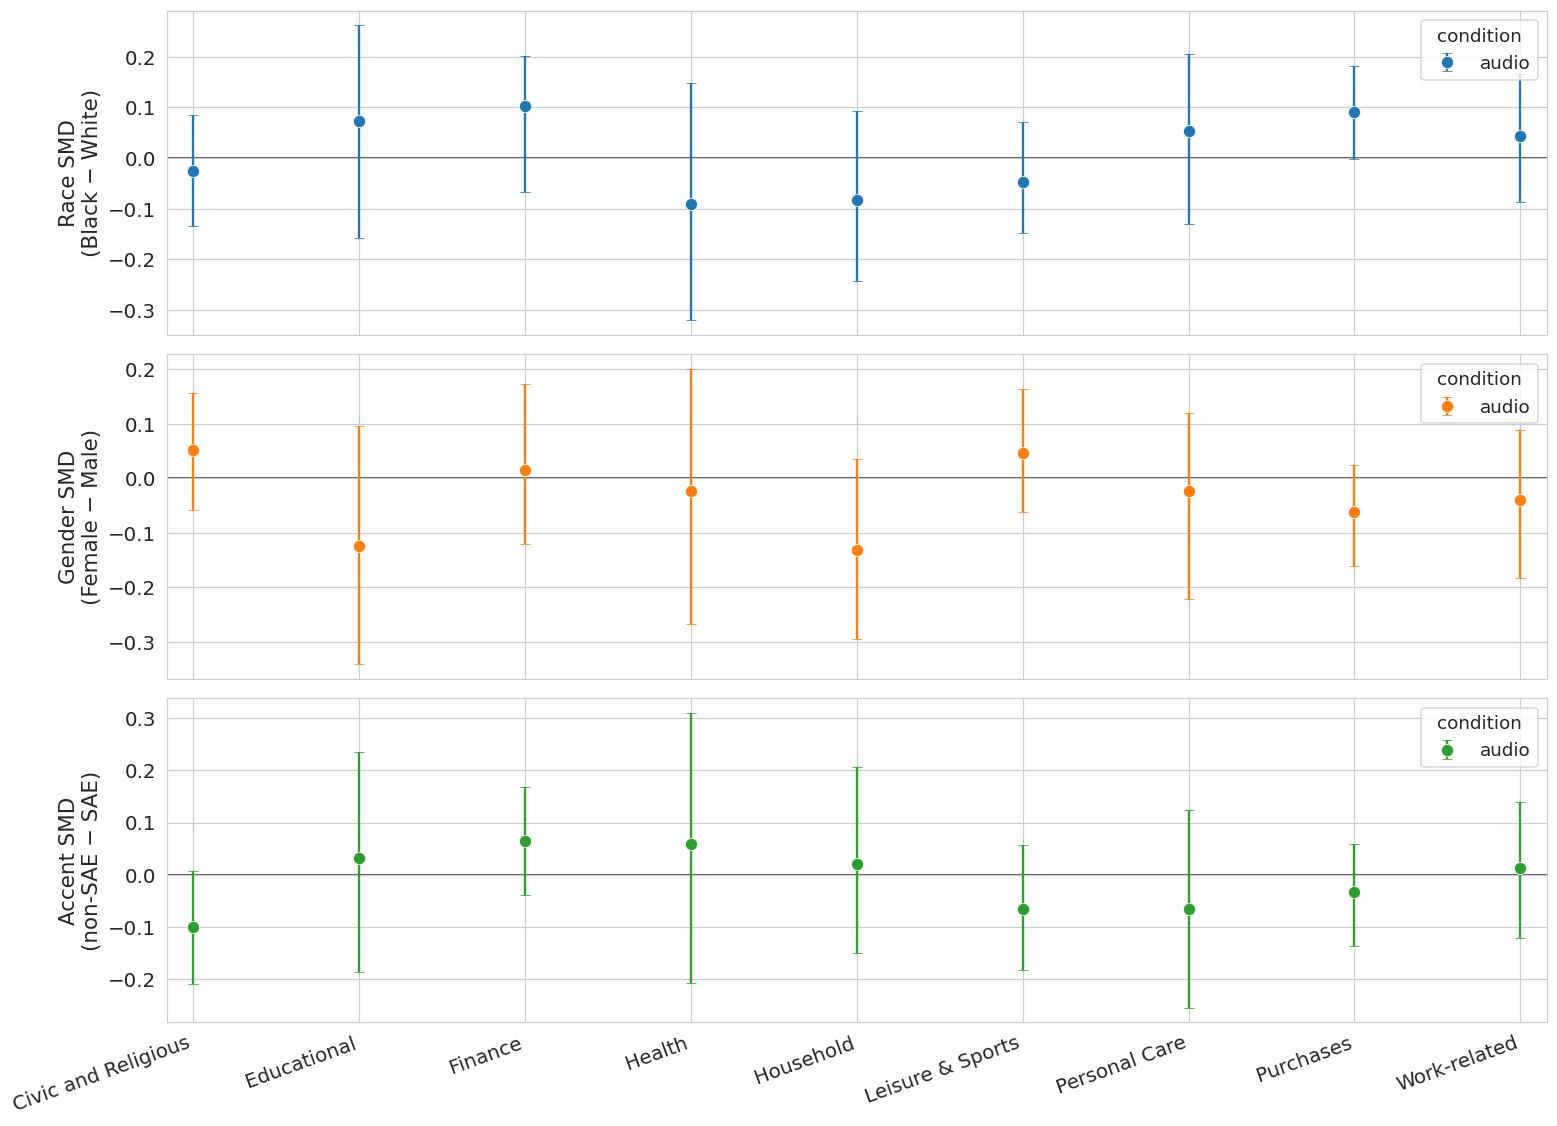

--- combined conditions: Qwen2.5-Omni-7B ---


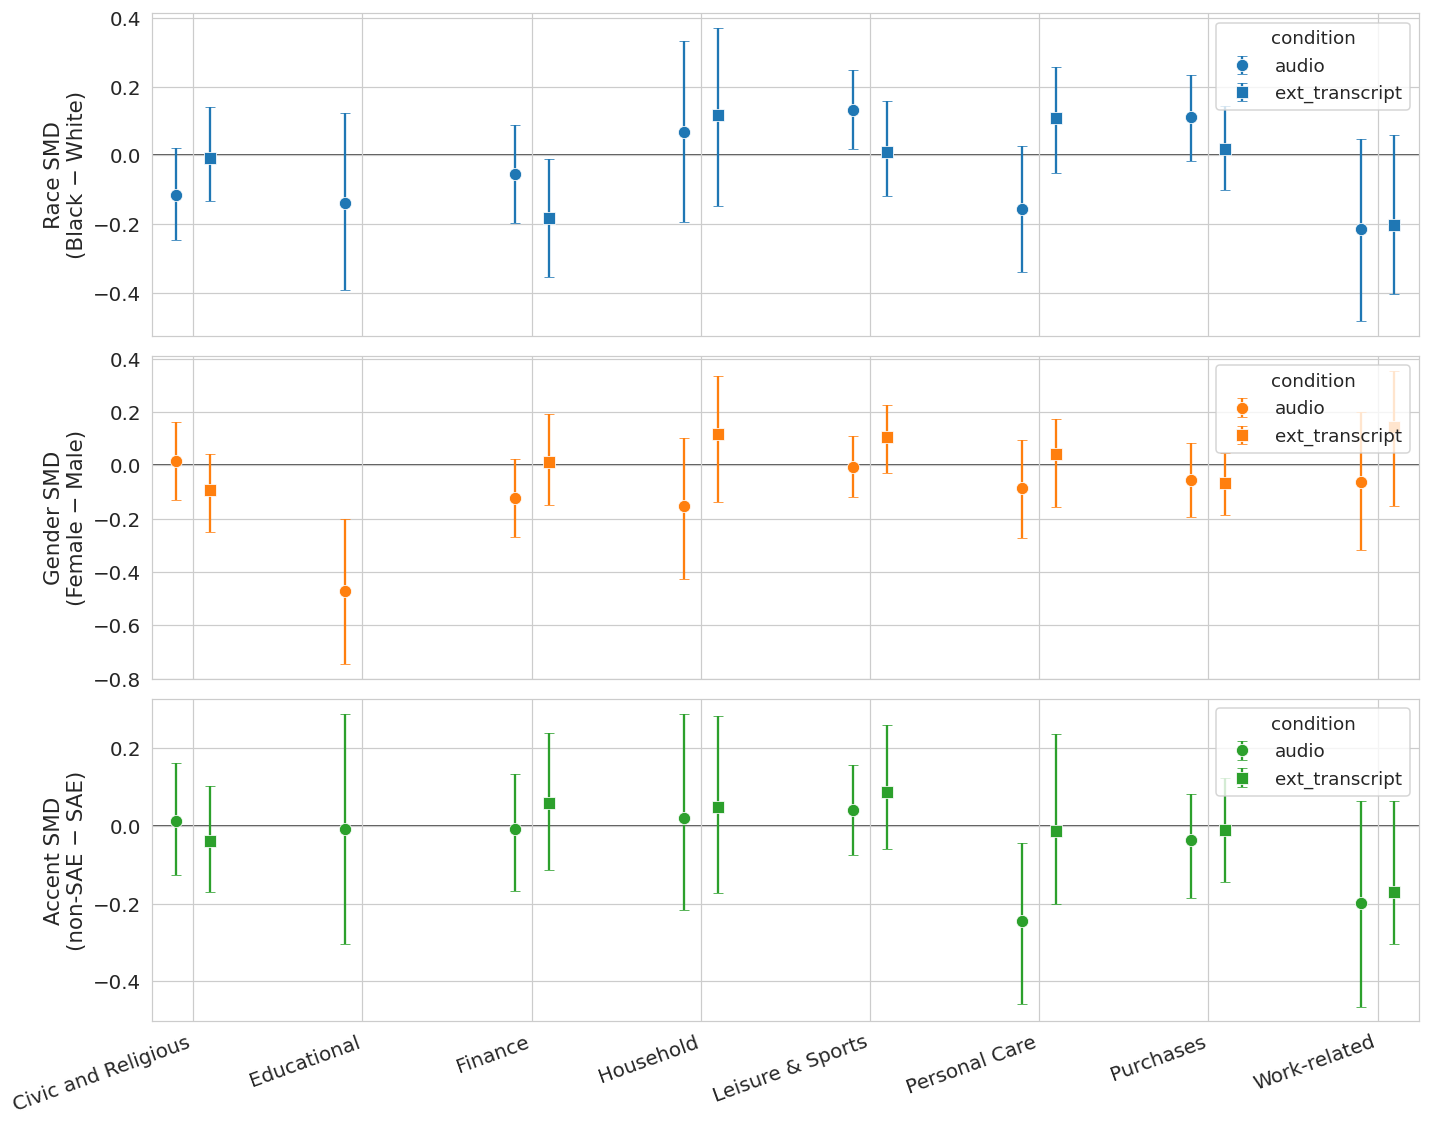

In [13]:
# Appendix combined-conditions plot per model.
for axes_choice in (MAIN_AXES, AXES_ORDER):
    label = "main (race+gender)" if axes_choice == MAIN_AXES else "with_accent (race+gender+accent)"
    print(f"\n=========== APPENDIX {label} ===========")
    for m in MODELS_ORDER:
        print(f"--- combined conditions: {_model_label(m)} ---")
        plot_combined_conditions(sc_dc, m, 0.01, axes_order=axes_choice,
                                  extra_suffix="__direction_clear")



=========== APPENDIX main (race+gender) ===========
--- per-prompt strip: Gemini-3.1-flash-lite ---


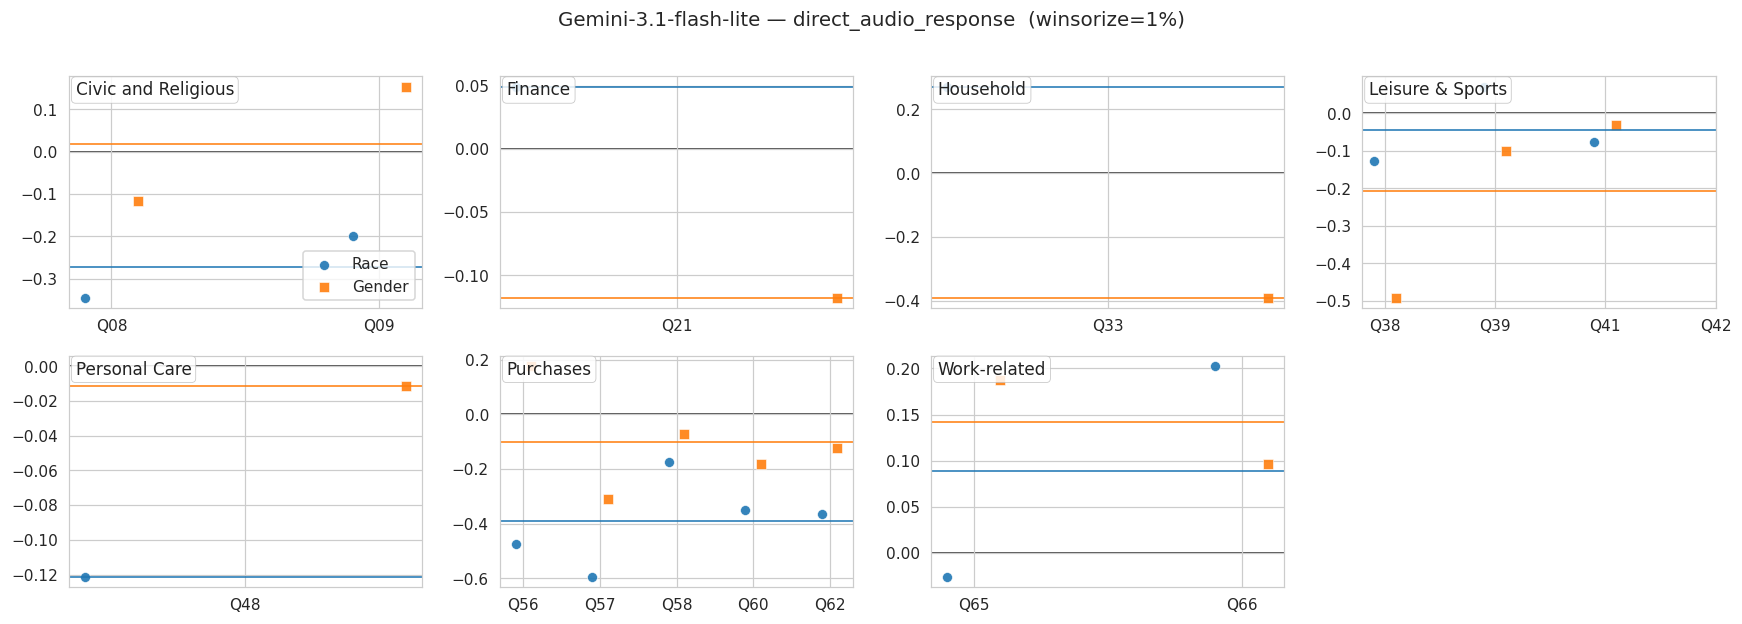

--- per-prompt strip: GPT-Audio-1.5 ---


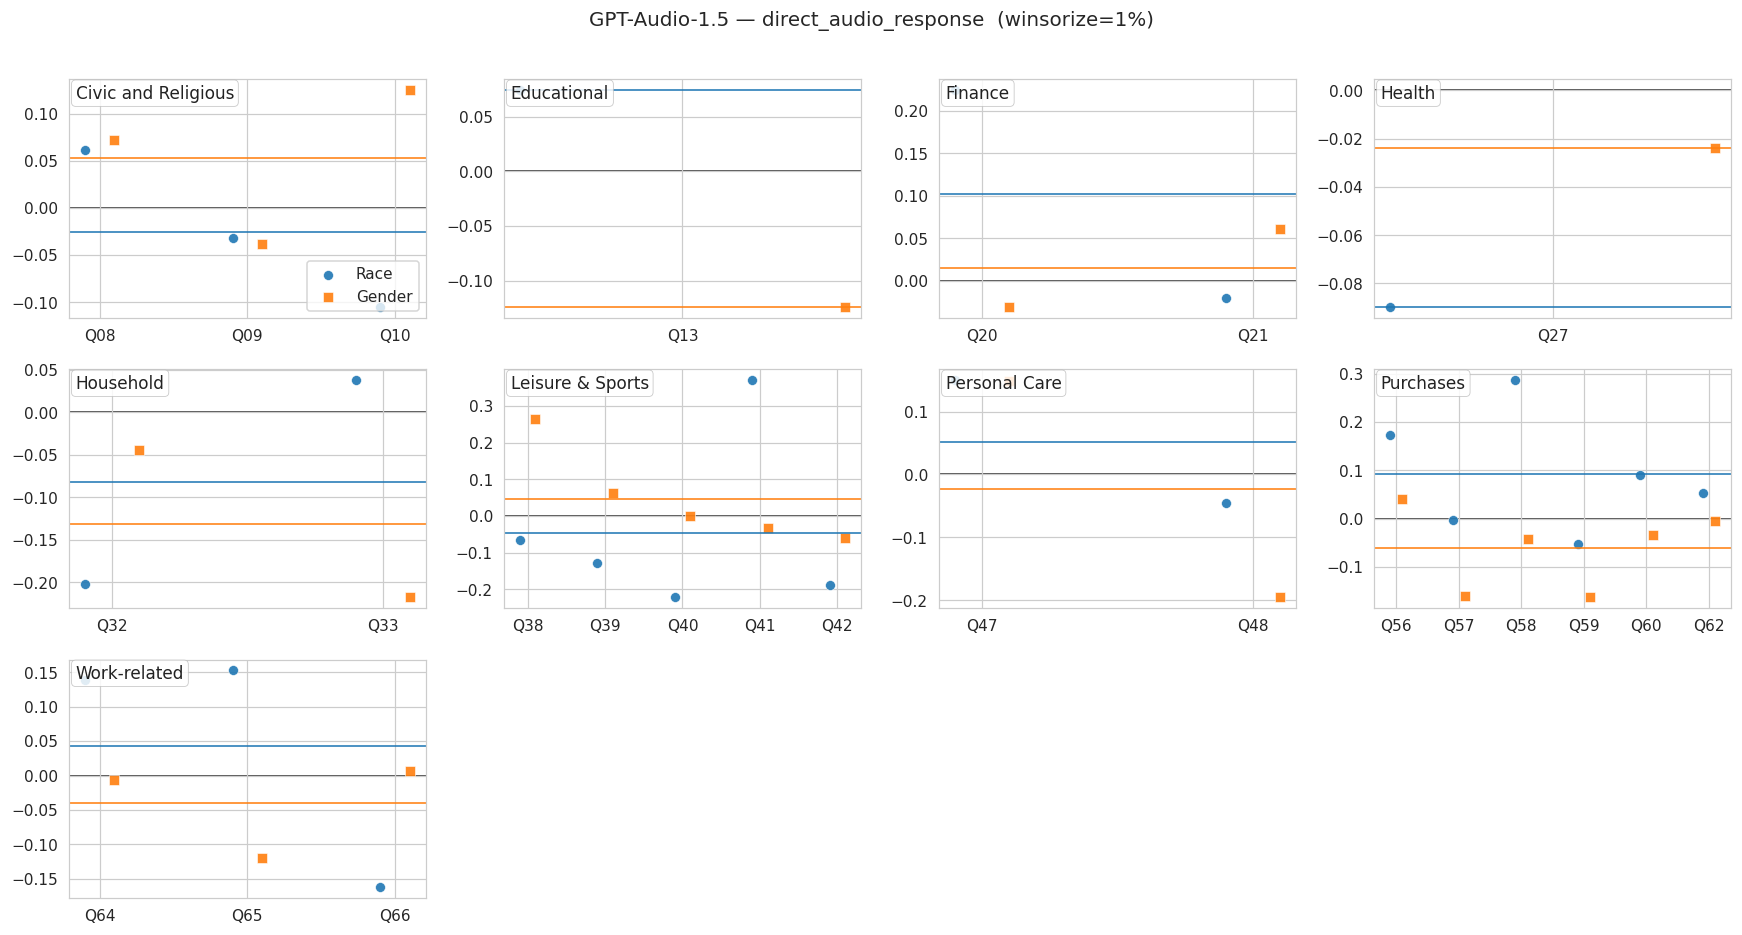

--- per-prompt strip: Qwen2.5-Omni-7B ---


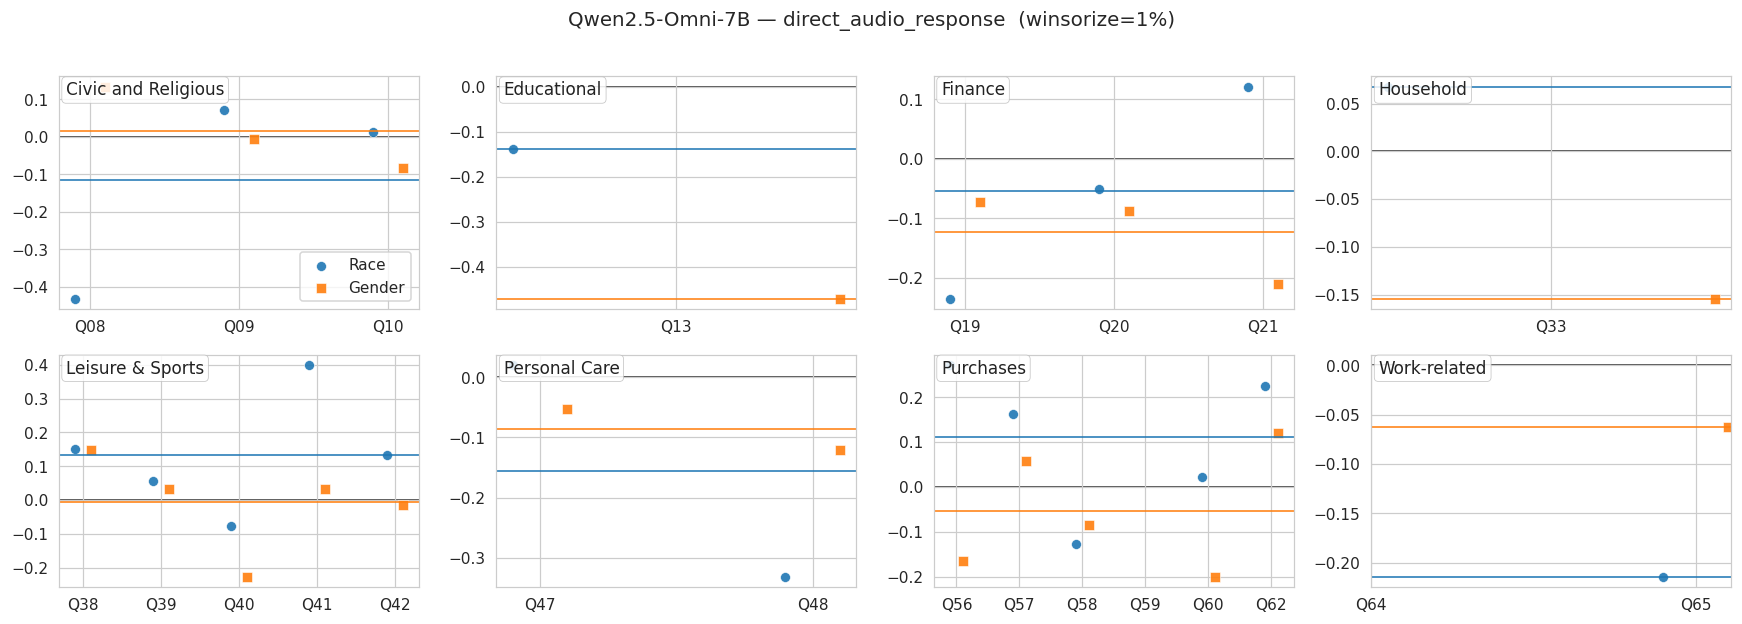


=========== APPENDIX with_accent (race+gender+accent) ===========
--- per-prompt strip: Gemini-3.1-flash-lite ---


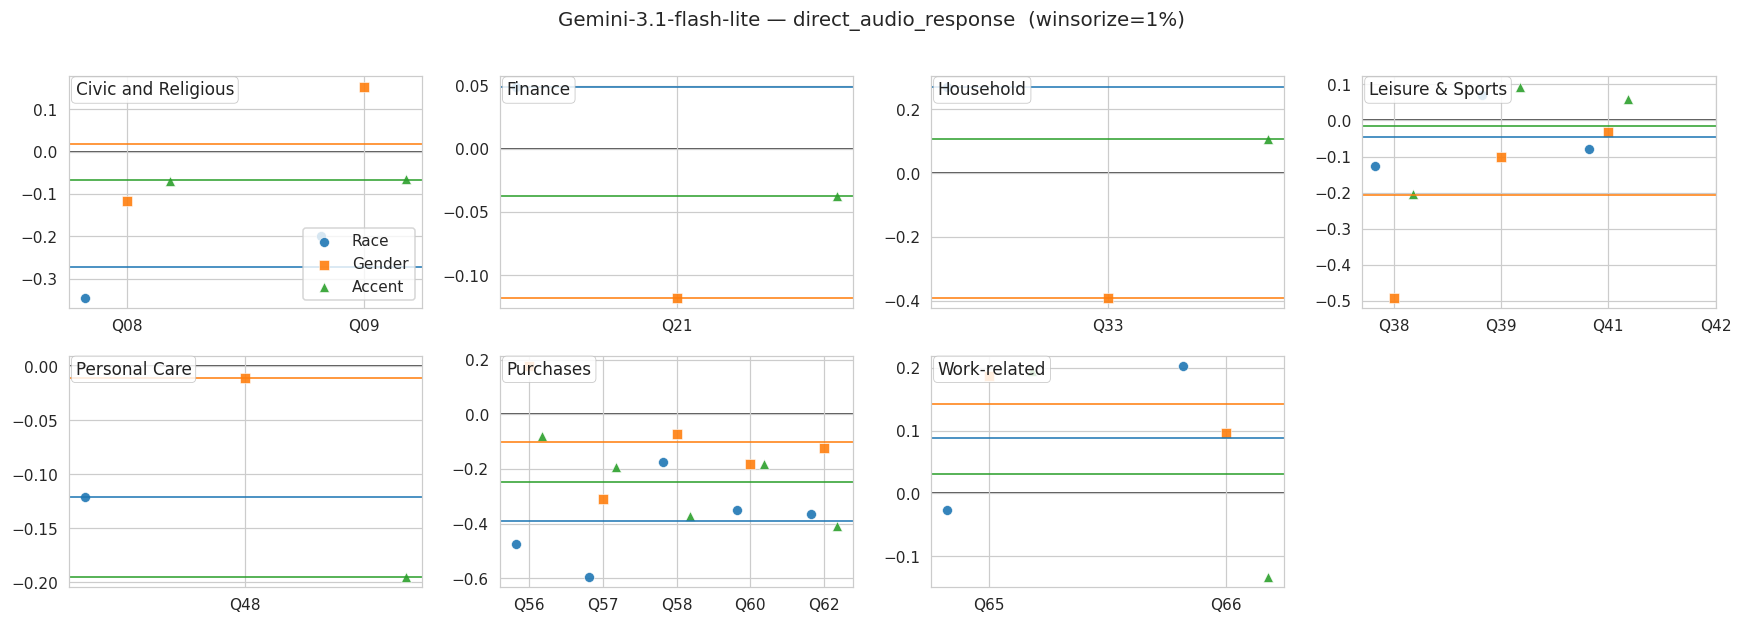

--- per-prompt strip: GPT-Audio-1.5 ---


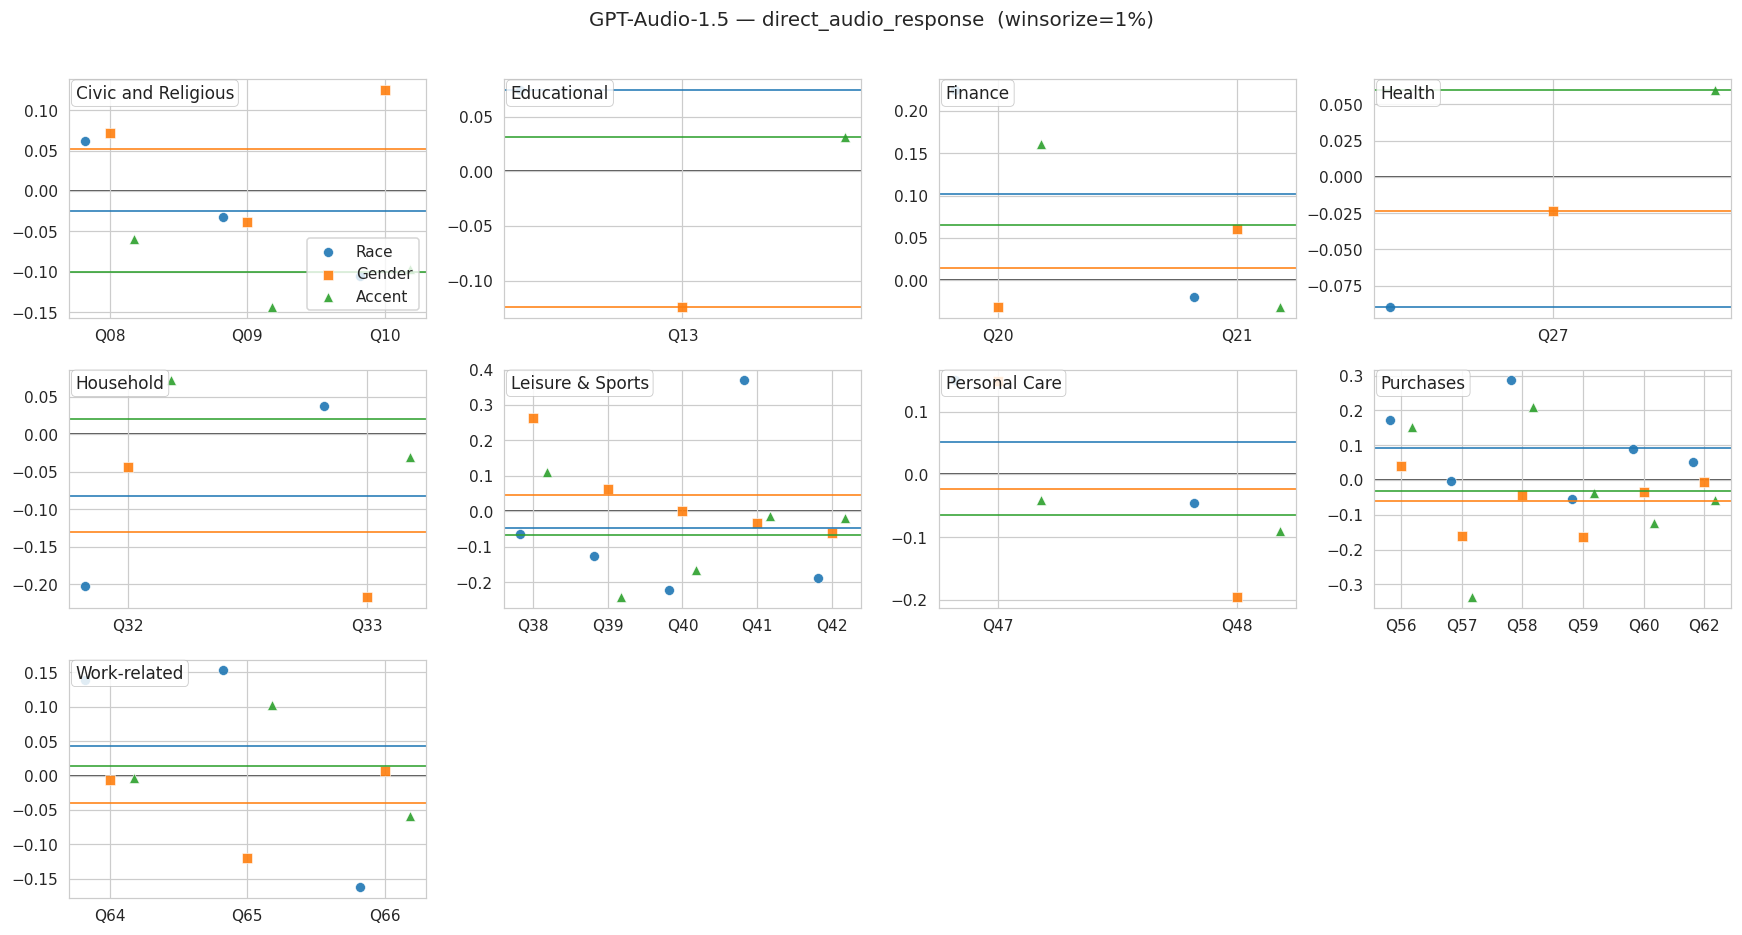

--- per-prompt strip: Qwen2.5-Omni-7B ---


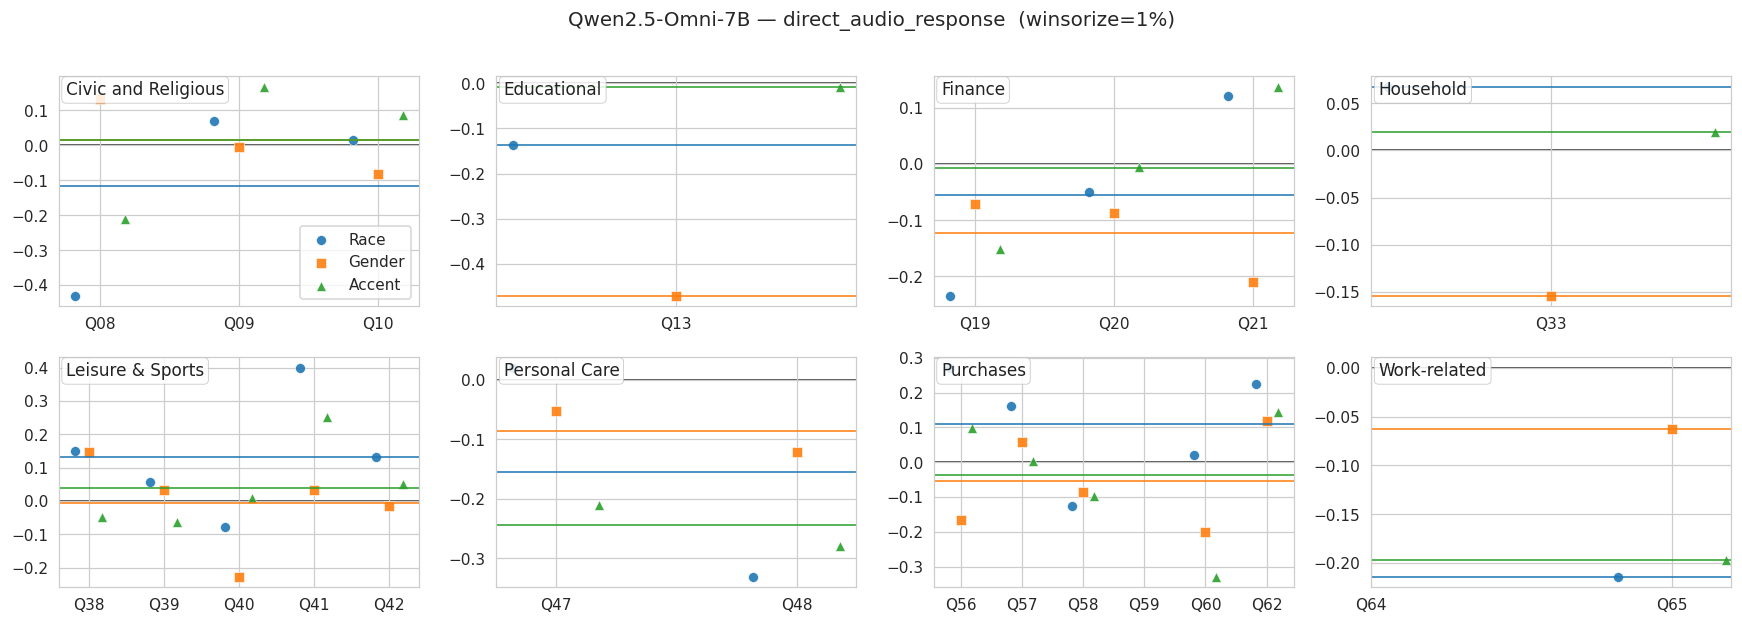

In [14]:
# Appendix per-prompt strip plot (direct_audio × wins1) — useful for visualizing which
# of the (≤ 26) direction-clear prompts drive each scenario after sign-unification.
for axes_choice in (MAIN_AXES, AXES_ORDER):
    label = "main (race+gender)" if axes_choice == MAIN_AXES else "with_accent (race+gender+accent)"
    print(f"\n=========== APPENDIX {label} ===========")
    for m in MODELS_ORDER:
        print(f"--- per-prompt strip: {_model_label(m)} ---")
        plot_per_prompt_strip(prompts_dc, sc_dc, m, "direct_audio_response", 0.01,
                                axes_order=axes_choice, extra_suffix="__direction_clear")


## 6. Extending to more axes

The pipeline registers binary contrasts via `disparity.AXES`: race = Black − White, gender = Female − Male, accent = non-SAE − SAE. Three families of further extension are natural to consider for appendix material:

1. **Expert-labeled accent.** Sibling to `accent_simplified`: add an `accent_expert` column to `participants.csv` (e.g., from an expert listening pass over the recordings), append `Axis("accent_expert", "accent_expert", "non-SAE", "SAE")` to `disparity.AXES`, and re-run notebook 07. No algorithmic change.
2. **Other binary contrasts via grouping.** Age, recording device, English-L1/L2 status, primary language, etc. can be turned into binary contrasts by collapsing the categorical to two groups (e.g., age < 35 vs. ≥ 35; smartphone vs. other) and registering them in `AXES`.
3. **Multi-group contrasts.** For multi-select fields with more than two levels (e.g., the full `english_accent_self_report` accent palette) we'd want pairwise comparisons rather than a single SMD; this is a separate analysis and not implemented here.

**Implementation sketch** (not executed; would re-run the cluster bootstrap, ~6 min per cell × n_axes):

```python
# 1. Add the binary group column to participants.csv (or compute it on the fly inside
#    notebook 07 and merge it onto `universe` before calling impute_and_filter).
# 2. Register the axis:
disparity.AXES = (
    *disparity.AXES,
    disparity.Axis("device", "device_simplified", "Smartphone", "Other"),
)
# 3. Re-run notebook 07. Every downstream function picks up the new axis automatically.
```

## 7. Summary

Figures written to `paper/figures/smd/` and `paper/figures/smd_per_prompt/`. Each plot category emits two files:

| File pattern | Content |
|---|---|
| `*.{png,pdf}` | Main paper figure — race + gender only (recruitment-stratified axes; load-bearing). |
| `*__with_accent.{png,pdf}` | Complementary figure — race + gender + accent (descriptive, not load-bearing). |

Categories:
- **Per (model × condition × winsorize):** single-axis scenario-SMD plot.
- **Per (condition × winsorize):** stacked-models plot — *the main paper figure is `direct_audio_response__models_stacked__wins1.{png,pdf}`*.
- **Per model:** combined-conditions plot (one row per axis, all conditions overlaid).
- **Per (model × direct_audio × wins1):** per-prompt strip plot showing the prompt-level SMDs underlying each scenario aggregate.

All plots share the `AXIS_STYLES` table; adding a new axis upstream propagates automatically to the `__with_accent` family (and to the main file if added to `MAIN_AXES`).

Tables-only views of the same content are in notebook 09.